# Multivariate, all for all

# STARTER

In [1]:
import sys
import pathlib

# Get project root (parent of generation/)
project_root = pathlib.Path().resolve().parent
sys.path.insert(0, str(project_root))

# DATA
### Step 0: Data generation and scaling

In [2]:
from scripts.data_generation.binder import Binder
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scripts.data_generation.tsdg import DynamicalSystem
from sklearn.preprocessing import MinMaxScaler

# --- Data Generation ---
model_name = 'lorenz63'
sigma = 10 
beta = 8/3
rho = 28
params = (sigma, beta, rho)
binder = Binder("scripts.systems.lorenz63", "lorenz63", params)
binder.import_module()      
model_fixed = binder.fixer()
t_span = (0, 100)
t_eval = np.linspace(t_span[0], t_span[1], 1000)
y0 = np.array([0.1, 0.1, 0.1])
ds1 = DynamicalSystem(model_fixed, y0, t_eval, notebook = True)
_ = ds1.solve()

# --- Convert to dataframe ---
sample = ds1.to_dataframe()

# Train and Test Split
Full = sample.values
n_samples = len(Full)

train_size = int(0.60 * n_samples)   # 70% for training
val_size = int(0.20 * n_samples)     # 10% for validation
test_size = n_samples - train_size - val_size  # remaining 20% for testing

train_data = Full[:train_size]
val_data = Full[train_size:train_size+val_size]
test_data = Full[train_size+val_size:]

# --- Scaling ---
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

# # We fit on train but immediately transform test here for simplicity
# test_scaled  = scaler.transform(test_data.reshape(-1, 1)).flatten()
# # If you want the prediction back in original units:
# # yhat = scaler.inverse_transform(yhat_scaled)

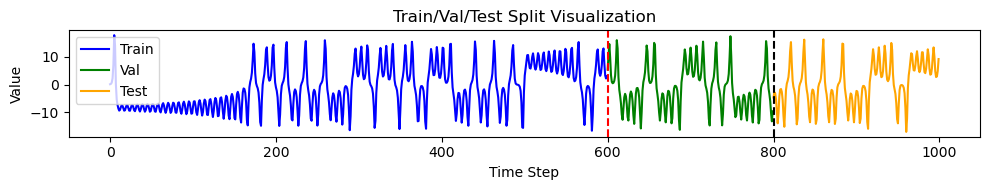

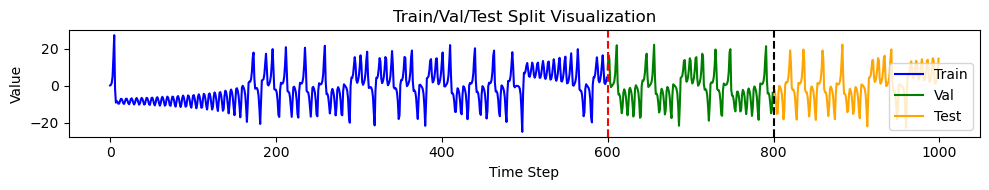

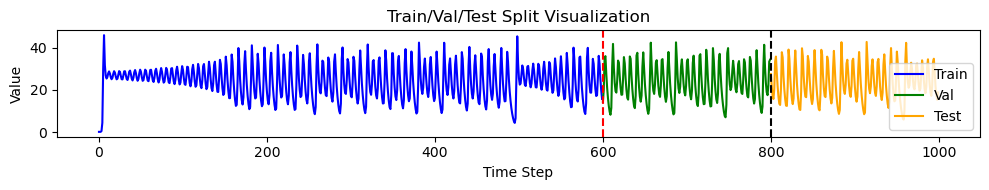

In [3]:
for i in range(len(sample.columns)):
    # Define x-axis ranges based on the lengths
    train_end = len(train_data[:,i])
    val_end = len(train_data[:,i]) + len(val_data[:,i])
    x_train = np.arange(train_end)
    x_val =np.arange(train_end, train_end + len(val_data[:,i]))
    x_test = np.arange(val_end, val_end + len(test_data[:,i]))
    # Plot
    plt.figure(figsize=(10, 2))
    plt.plot(x_train, train_data[:,i], label='Train', color='blue')
    plt.plot(x_val, val_data[:,i], label='Val', color='green')
    plt.plot(x_test, test_data[:,i], label='Test', color='orange')

    # Optional vertical line to indicate the split
    plt.axvline(x=train_end, color='red', linestyle='--') #label='Train/Test Split'
    plt.axvline(x=val_end, color='black', linestyle='--') #label='Train/Test Split'
    plt.legend()
    plt.title("Train/Val/Test Split Visualization")
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.tight_layout()
    plt.show()

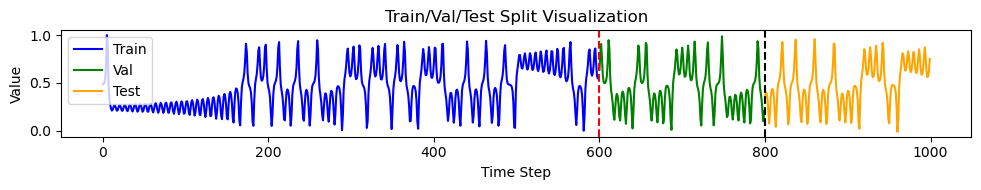

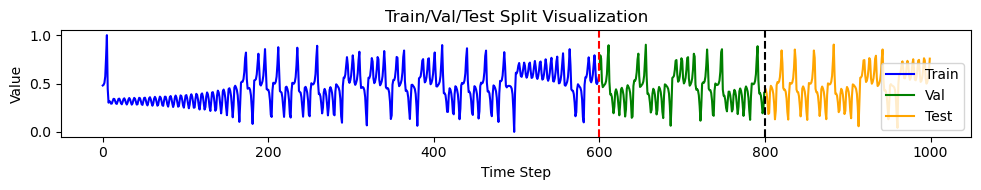

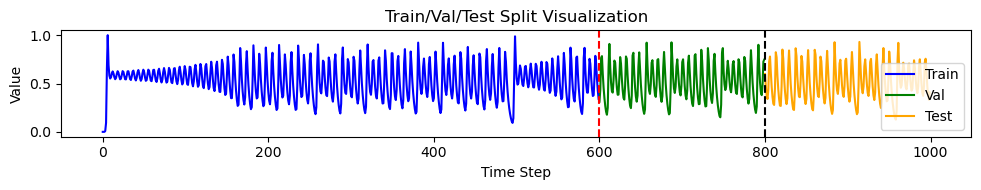

In [4]:
for i in range(len(sample.columns)):
    # Define x-axis ranges based on the lengths
    train_end = len(train_scaled[:,i])
    val_end = len(train_scaled[:,i]) + len(val_scaled[:,i])
    x_train = np.arange(train_end)
    x_val =np.arange(train_end, train_end + len(val_scaled[:,i]))
    x_test = np.arange(val_end, val_end + len(test_scaled[:,i]))
    # Plot
    plt.figure(figsize=(10, 2))
    plt.plot(x_train, train_scaled[:,i], label='Train', color='blue')
    plt.plot(x_val, val_scaled[:,i], label='Val', color='green')
    plt.plot(x_test, test_scaled[:,i], label='Test', color='orange')

    # Optional vertical line to indicate the split
    plt.axvline(x=train_end, color='red', linestyle='--') #label='Train/Test Split'
    plt.axvline(x=val_end, color='black', linestyle='--') #label='Train/Test Split'
    plt.legend()
    plt.title("Train/Val/Test Split Visualization")
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.tight_layout()
    plt.show()

# Recursive

### Step 1: Data Preparation

In [ ]:
def recursive_mv_afa(sequences, n_steps_in):

In [5]:
from numpy import array

In [6]:
# split a multivariate sequence into samples
def split_sequences(sequences, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[end_ix:out_end_ix, :]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [7]:
# choose a number of time steps
n_steps_in, n_steps_out = 1, 1
# convert into input/output
X, y = split_sequences(train_scaled, n_steps_in, n_steps_out)

In [8]:
X.shape

(599, 1, 3)

In [9]:
for i in range(len(X)):
    print(X[i], y[i])

[[4.86447589e-01 4.79738719e-01 4.30745881e-04]] [[0.48986985 0.48666957 0.        ]]
[[0.48986985 0.48666957 0.        ]] [[5.03822071e-01 5.06901295e-01 4.17611642e-04]]
[[5.03822071e-01 5.06901295e-01 4.17611642e-04]] [[0.54943381 0.57203917 0.0087363 ]]
[[0.54943381 0.57203917 0.0087363 ]] [[0.69215139 0.76680912 0.09389267]]
[[0.69215139 0.76680912 0.09389267]] [[1.         1.         0.65089077]]
[[1.         1.         0.65089077]] [[0.89023684 0.44427998 1.        ]]
[[0.89023684 0.44427998 1.        ]] [[0.48449624 0.30205179 0.68967235]]
[[0.48449624 0.30205179 0.68967235]] [[0.32638191 0.31964645 0.5822419 ]]
[[0.32638191 0.31964645 0.5822419 ]] [[0.27010655 0.30984922 0.55180352]]
[[0.27010655 0.30984922 0.55180352]] [[0.23275226 0.29136512 0.56664925]]
[[0.23275226 0.29136512 0.56664925]] [[0.21071621 0.29309198 0.60586776]]
[[0.21071621 0.29309198 0.60586776]] [[0.21951638 0.31932111 0.62521321]]
[[0.21951638 0.31932111 0.62521321]] [[0.24822641 0.34168584 0.60394612]]
[[

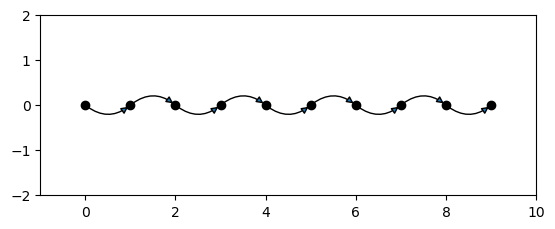

In [10]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

xs = list(range(10))
ys = [0]*10

fig, ax = plt.subplots()

ax.plot(xs, ys, 'ko')

for i in range(len(xs)-1):
    x0, y0 = xs[i], ys[i]
    x1, y1 = xs[i+1], ys[i+1]

    xm = (x0 + x1) / 2
    ym = (y0 + y1) / 2

    # Alternate curvature
    direction = 1 if i % 2 == 0 else -1

    # Shift midpoint vertically to create the arc height
    ctrl_y = ym + 0.5 * direction

    arrow = FancyArrowPatch(
        (x0, y0),
        (x1, y1),
        connectionstyle=f"arc3,rad={0.4*direction}",
        arrowstyle="-|>",
        mutation_scale=10
    )
    ax.add_patch(arrow)

ax.set_xlim(-1, 10)
ax.set_ylim(-2, 2)
ax.set_aspect('equal')
plt.show()


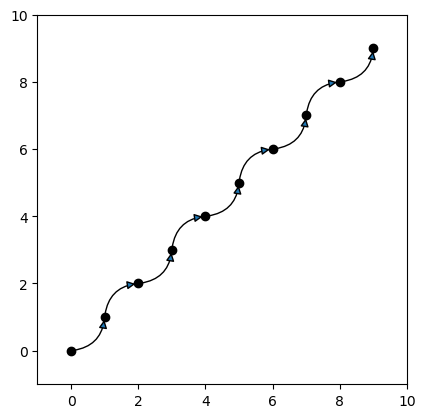

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

def plot_identity_with_arcs(n):
    xs = list(range(n))
    ys = xs[:]   # identity mapping

    fig, ax = plt.subplots()
    ax.plot(xs, ys, 'ko')  # points

    for i in range(n - 1):
        x0, y0 = xs[i], ys[i]
        x1, y1 = xs[i+1], ys[i+1]

        # alternate curvature: +, -, +, -, ...
        direction = 1 if i % 2 == 0 else -1

        arrow = FancyArrowPatch(
            (x0, y0),
            (x1, y1),
            connectionstyle=f"arc3,rad={0.4 * direction}",
            arrowstyle="-|>",
            mutation_scale=12
        )
        ax.add_patch(arrow)

    ax.set_xlim(-1, n)
    ax.set_ylim(min(ys)-1, max(ys)+1)
    ax.set_aspect("equal")
    plt.show()

# Example
plot_identity_with_arcs(10)


# DIRECT-MULTIVARIATE-ALL_FOR_ALL

In [20]:
# split a multivariate sequence into samples
def split_sequences_v1(sequences, n_steps_in, n_steps_out, skip):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences) - skip:
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[skip + end_ix:out_end_ix + skip , :]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

Lorenz data

In [ ]:
n_steps_in = 1
n_steps_out = 1
horizon = 20
datasets = {}
for i in range(horizon):
    skip = i
    X, y = split_sequences_v1(train_scaled, n_steps_in, n_steps_out, skip)
    X = X.reshape((X.shape[0], X.shape[1], X.shape[2]))
    datasets[i] = (X, y)  # store as tuple

Made Up Data

In [45]:
from numpy import array
# define input sequence
in_seq1 = array([i for i in range(0, 10, 1)])
in_seq2 = array([i for i in range(0, 20, 2)])

In [46]:
in_seq1

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [47]:
in_seq2

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

In [48]:
out_seq = array([in_seq1[i] + in_seq2[i] for i in range(len(in_seq1))])

In [49]:
from numpy import hstack
# convert to [row, columns] structure

in_seq1 = in_seq1.reshape((len(in_seq1), 1))
in_seq2 = in_seq2.reshape((len(in_seq2), 1))
out_seq = out_seq.reshape((len(out_seq), 1))

#horizontally stack columns
dataset = hstack((in_seq1, in_seq2, out_seq))

In [50]:
dataset

array([[ 0,  0,  0],
       [ 1,  2,  3],
       [ 2,  4,  6],
       [ 3,  6,  9],
       [ 4,  8, 12],
       [ 5, 10, 15],
       [ 6, 12, 18],
       [ 7, 14, 21],
       [ 8, 16, 24],
       [ 9, 18, 27]])

In [61]:
n_steps_in = 1
n_steps_out = 1
horizon = 4
datasets = {}
for i in range(horizon):
    skip = i 
    X, y = split_sequences_v1(dataset, n_steps_in, n_steps_out, skip)
    X = X.reshape((X.shape[0], X.shape[1], X.shape[2]))
    datasets[i] = (X, y)  # store as tuple

In [62]:
for i in datasets:
    print(i, end=' ')

0 1 2 3 

In [65]:
X, y = datasets[3
            ]
print(X.shape)
print(y.shape)
for xi, yi in zip(X, y):
    print(xi,yi)

(6, 1, 3)
(6, 1, 3)
[[0 0 0]] [[ 4  8 12]]
[[1 2 3]] [[ 5 10 15]]
[[2 4 6]] [[ 6 12 18]]
[[3 6 9]] [[ 7 14 21]]
[[ 4  8 12]] [[ 8 16 24]]
[[ 5 10 15]] [[ 9 18 27]]


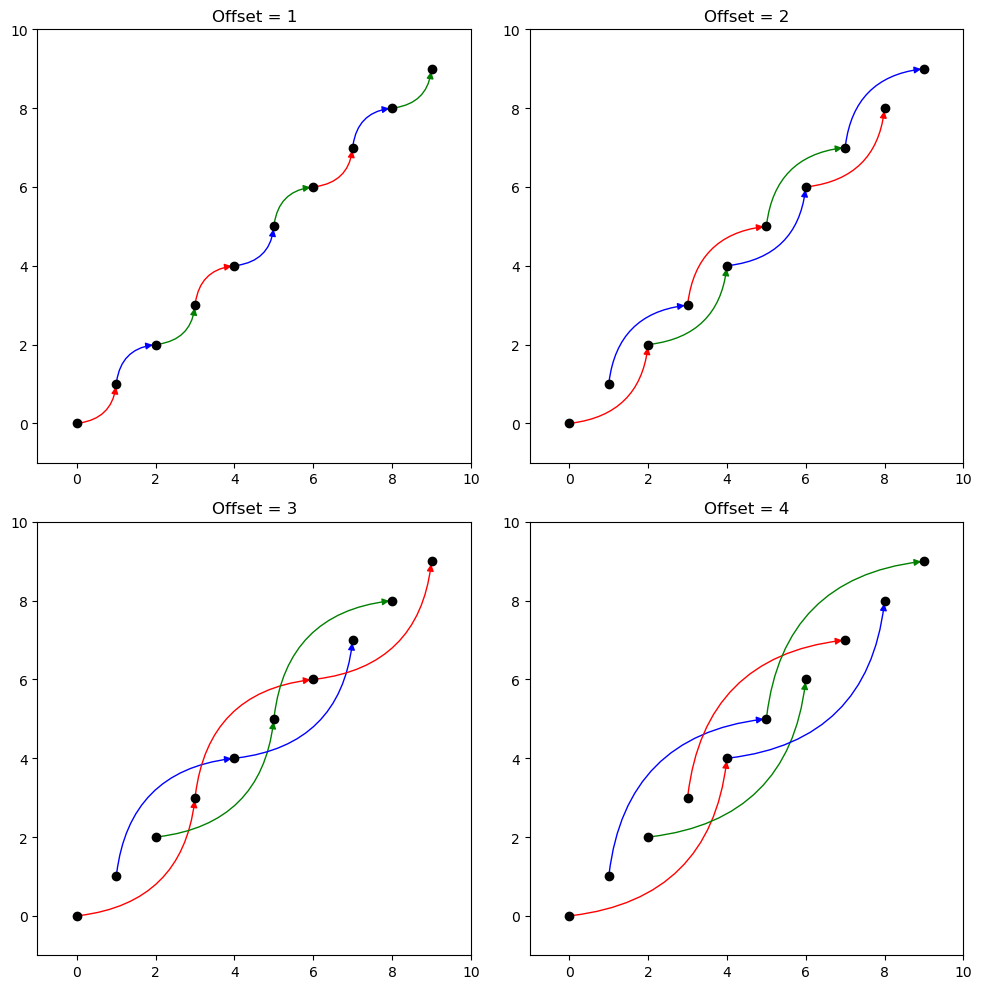

In [76]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

def draw_arcs(ax, n, offset):
    xs = list(range(n))
    ys = xs[:]  # identity

    ax.plot(xs, ys, 'ko')  # points

    colors = ['red', 'blue', 'green']

    for i in range(n):
        j = i + offset
        if j >= n:
            break

        x0, y0 = xs[i], ys[i]
        x1, y1 = xs[j], ys[j]

        direction = 1 if i % 2 == 0 else -1
        color = colors[i % len(colors)]

        arrow = FancyArrowPatch(
            (x0, y0),
            (x1, y1),
            connectionstyle=f"arc3,rad={0.4 * direction}",
            arrowstyle="-|>",
            mutation_scale=10,
            color=color
        )

        ax.add_patch(arrow)

    ax.set_title(f"Offset = {offset}")
    ax.set_xlim(-1, n)
    ax.set_ylim(-1, n)
    ax.set_aspect("equal")

def plot_all(n=10):
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))

    offsets = [1, 2, 3, 4]
    idx = 0
    for r in range(2):
        for c in range(2):
            draw_arcs(axs[r][c], n, offsets[idx])
            idx += 1

    plt.tight_layout()
    plt.show()

# Example:
plot_all(10)


# DIREC-MULTIVARIATE-ALL_FOR_ALL
Dividir el horizonte $H$ en bloques $B$ de modo que $H/B = N$. Se entrena un modelo para predecir $B$ pasos, y la predicción del bloque se reutiliza como entrada del siguiente bloque hasta alcanzar $H$. 

In [ ]:
# split a multivariate sequence into samples
def split_sequences(sequences, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[end_ix:out_end_ix, :]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [ ]:
# # choose a number of time steps
# n_steps_in, n_steps_out = 2, 2
# # convert into input/output
# X, y = split_sequences(train_scaled, n_steps_in, n_steps_out)

# choose a number of time steps
n_steps_in, n_steps_out = 2, 2
# convert into input/output
X, y = split_sequences(dataset, n_steps_in, n_steps_out)

In [67]:
for i in range(len(X)):
    print(X[i], y[i])

[[0 0 0]
 [1 2 3]] [[2 4 6]
 [3 6 9]]
[[1 2 3]
 [2 4 6]] [[ 3  6  9]
 [ 4  8 12]]
[[2 4 6]
 [3 6 9]] [[ 4  8 12]
 [ 5 10 15]]
[[ 3  6  9]
 [ 4  8 12]] [[ 5 10 15]
 [ 6 12 18]]
[[ 4  8 12]
 [ 5 10 15]] [[ 6 12 18]
 [ 7 14 21]]
[[ 5 10 15]
 [ 6 12 18]] [[ 7 14 21]
 [ 8 16 24]]
[[ 6 12 18]
 [ 7 14 21]] [[ 8 16 24]
 [ 9 18 27]]


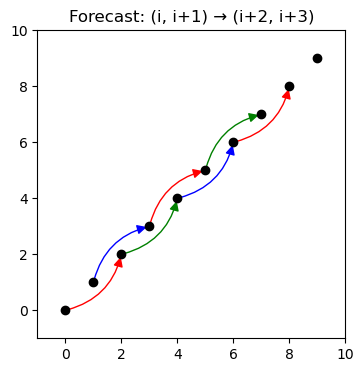

In [77]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

def plot_pair_forecasts(n=10):
    xs = list(range(n))
    ys = xs[:]  # identity

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(xs, ys, 'ko')

    colors = ['red', 'blue', 'green']

    for i in range(n - 3):
        # input pair (i, i+1)
        x0 = xs[i]
        y0 = ys[i]

        # forecast target pair starts at i+2
        x1 = xs[i + 2]
        y1 = ys[i + 2]

        # alternate curvature
        direction = 1 if i % 2 == 0 else -1

        # select arrow color
        color = colors[i % len(colors)]

        arrow = FancyArrowPatch(
            (x0, y0),
            (x1, y1),
            connectionstyle=f"arc3,rad={0.3 * direction}",
            arrowstyle="-|>",
            mutation_scale=14,
            color=color
        )
        ax.add_patch(arrow)

    ax.set_xlim(-1, n)
    ax.set_ylim(-1, n)
    ax.set_aspect("equal")
    ax.set_title("Forecast: (i, i+1) → (i+2, i+3)")
    plt.show()

# Example
plot_pair_forecasts(10)


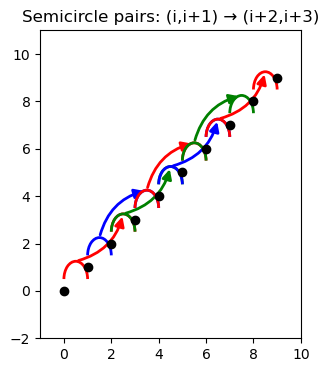

In [78]:
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, FancyArrowPatch

def plot_pairs_with_semicircles(n=10):
    xs = list(range(n))
    ys = xs[:]  # identity line

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(xs, ys, 'ko')

    colors = ['red', 'blue', 'green']

    for i in range(n - 3):
        color = colors[i % len(colors)]

        # input pair
        x_in1, x_in2 = xs[i], xs[i+1]
        xm_in = (x_in1 + x_in2) / 2
        ym_in = (ys[i] + ys[i+1]) / 2

        # output pair
        x_out1, x_out2 = xs[i+2], xs[i+3]
        xm_out = (x_out1 + x_out2) / 2
        ym_out = (ys[i+2] + ys[i+3]) / 2

        # semicircle height
        radius = (x_in2 - x_in1) / 2

        # upward semicircle for inputs
        arc_in = Arc(
            (xm_in, ym_in),
            width=(x_in2 - x_in1),
            height=1.5,
            theta1=0, theta2=180,
            color=color,
            lw=2
        )
        ax.add_patch(arc_in)

        # upward semicircle for outputs
        arc_out = Arc(
            (xm_out, ym_out),
            width=(x_out2 - x_out1),
            height=1.5,
            theta1=0, theta2=180,
            color=color,
            lw=2
        )
        ax.add_patch(arc_out)

        # arrow connecting centers of semicircles
        direction = 1 if i % 2 == 0 else -1  # alternate curvature
        arrow = FancyArrowPatch(
            (xm_in, ym_in + 0.75),
            (xm_out, ym_out + 0.75),
            connectionstyle=f"arc3,rad={0.3 * direction}",
            arrowstyle="-|>",
            mutation_scale=14,
            color=color,
            lw=2
        )
        ax.add_patch(arrow)

    ax.set_xlim(-1, n)
    ax.set_ylim(-2, n+1)
    ax.set_aspect("equal")
    ax.set_title("Semicircle pairs: (i,i+1) → (i+2,i+3)")
    plt.show()

# Example
plot_pairs_with_semicircles(10)


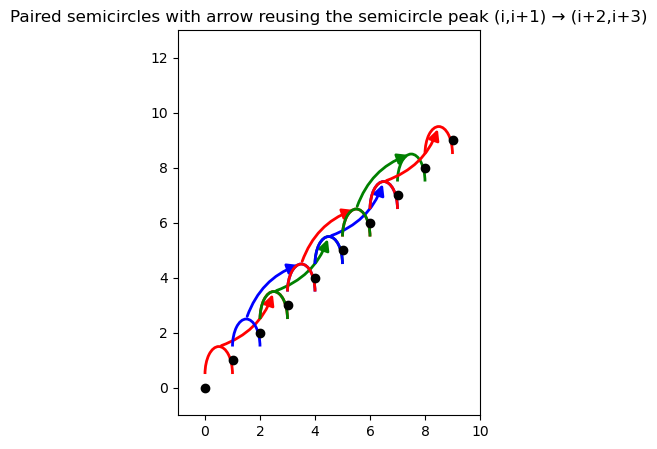

In [79]:
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, FancyArrowPatch

def plot_semicircle_forecasts(n=10):
    xs = list(range(n))
    ys = xs[:]  # identity

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(xs, ys, 'ko')

    colors = ['red', 'blue', 'green']

    semicircle_height = 2.0  # visual size
    arrow_vertical_offset = semicircle_height / 2

    for i in range(n - 3):
        color = colors[i % len(colors)]

        # INPUT pair
        x0, x1 = xs[i], xs[i+1]
        xm_in = (x0 + x1) / 2
        ym_in = (ys[i] + ys[i+1]) / 2

        # OUTPUT pair
        y0, y1 = xs[i+2], xs[i+3]
        xm_out = (y0 + y1) / 2
        ym_out = (ys[i+2] + ys[i+3]) / 2

        # ---- SEMICIRCLES ----
        # Input semicircle
        arc_in = Arc(
            (xm_in, ym_in),
            width=(x1 - x0),
            height=semicircle_height,
            theta1=0, theta2=180,
            color=color, lw=2
        )
        ax.add_patch(arc_in)

        # Output semicircle
        arc_out = Arc(
            (xm_out, ym_out),
            width=(y1 - y0),
            height=semicircle_height,
            theta1=0, theta2=180,
            color=color, lw=2
        )
        ax.add_patch(arc_out)

        # ---- ARROW ----
        # Start at top of input semicircle
        start = (xm_in, ym_in + arrow_vertical_offset)
        # End at top of output semicircle
        end = (xm_out, ym_out + arrow_vertical_offset)

        # Alternate curvature
        direction = 1 if i % 2 == 0 else -1

        arrow = FancyArrowPatch(
            start,
            end,
            connectionstyle=f"arc3,rad={0.25 * direction}",
            arrowstyle="-|>",
            mutation_scale=16,
            color=color,
            lw=2
        )
        ax.add_patch(arrow)

    ax.set_xlim(-1, n)
    ax.set_ylim(-1, n + 3)
    ax.set_aspect("equal")
    ax.set_title("Paired semicircles with arrow reusing the semicircle peak (i,i+1) → (i+2,i+3)")
    plt.show()

# Example
plot_semicircle_forecasts(10)


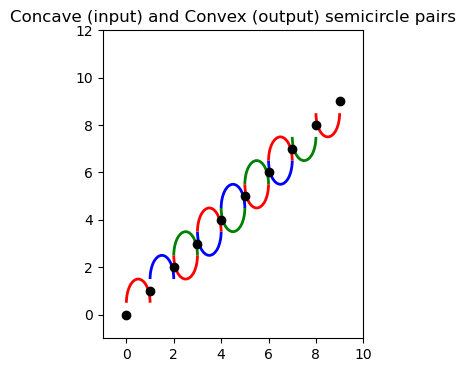

In [80]:
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

def plot_semicircle_pairs(n=10):
    xs = list(range(n))
    ys = xs[:]  # identity

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(xs, ys, 'ko')

    colors = ["red", "blue", "green"]

    semicircle_height = 2.0

    for i in range(n - 3):
        color = colors[i % len(colors)]

        # Input pair (concave, upward)
        x0, x1 = xs[i], xs[i+1]
        xm_in = (x0 + x1) / 2
        ym_in = (ys[i] + ys[i+1]) / 2

        concave = Arc(
            (xm_in, ym_in),
            width=(x1 - x0),
            height=semicircle_height,
            theta1=0, theta2=180,   # upward arc
            lw=2, color=color
        )
        ax.add_patch(concave)

        # Output pair (convex, downward)
        y0, y1 = xs[i+2], xs[i+3]
        xm_out = (y0 + y1) / 2
        ym_out = (ys[i+2] + ys[i+3]) / 2

        convex = Arc(
            (xm_out, ym_out),
            width=(y1 - y0),
            height=semicircle_height,
            theta1=180, theta2=360,  # downward arc
            lw=2, color=color
        )
        ax.add_patch(convex)

    ax.set_xlim(-1, n)
    ax.set_ylim(-1, n + 2)
    ax.set_aspect("equal")
    ax.set_title("Concave (input) and Convex (output) semicircle pairs")
    plt.show()

# Example
plot_semicircle_pairs(10)


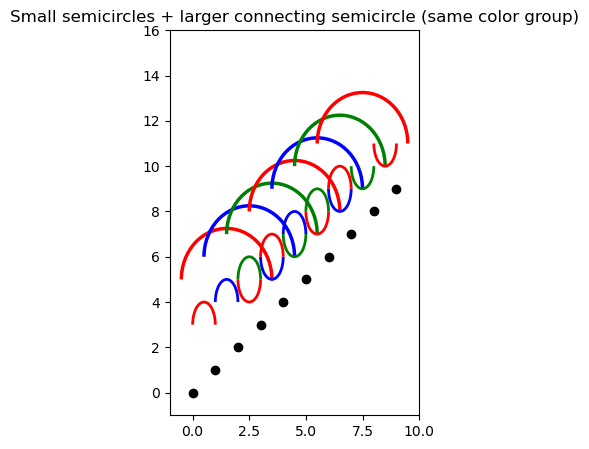

In [81]:
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

def plot_grouped_semicircles(n=10):
    xs = list(range(n))
    ys = xs[:]  # identity

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(xs, ys, 'ko')

    colors = ["red", "blue", "green"]

    # Vertical lift for the semicircles
    base_offset = 2.5           # moves small arcs above the points
    small_height = 2.0
    big_height = 4.5            # bigger arc

    for i in range(n - 3):
        color = colors[i % len(colors)]

        # Input pair
        x0, x1 = xs[i], xs[i+1]
        xm_in = (x0 + x1) / 2
        ym_in = (ys[i] + ys[i+1]) / 2 + base_offset

        # Output pair
        y0, y1 = xs[i+2], xs[i+3]
        xm_out = (y0 + y1) / 2
        ym_out = (ys[i+2] + ys[i+3]) / 2 + base_offset

        # ----- SMALL SEMICIRCLES -----
        # Concave input
        arc_in = Arc(
            (xm_in, ym_in),
            width=(x1 - x0),
            height=small_height,
            theta1=0, theta2=180,
            lw=2, color=color
        )
        ax.add_patch(arc_in)

        # Convex output
        arc_out = Arc(
            (xm_out, ym_out),
            width=(y1 - y0),
            height=small_height,
            theta1=180, theta2=360,
            lw=2, color=color
        )
        ax.add_patch(arc_out)

        # ----- BIG SEMICIRCLE CONNECTING THEM -----
        big_center_x = (xm_in + xm_out) / 2
        big_center_y = (ym_in + ym_out) / 2 + 1.0  # slight lift to visually separate

        big_width = xm_out - xm_in  # horizontal span
        # ensure positive width
        big_width = abs(big_width)

        big_arc = Arc(
            (big_center_x, big_center_y),
            width=big_width * 2.0,    # span covers both small arcs
            height=big_height,
            theta1=0, theta2=180,     # big concave arc upward
            lw=2.5, color=color
        )
        ax.add_patch(big_arc)

    ax.set_xlim(-1, n)
    ax.set_ylim(-1, n + 6)
    ax.set_aspect("equal")
    ax.set_title("Small semicircles + larger connecting semicircle (same color group)")
    plt.show()

# Example
plot_grouped_semicircles(10)


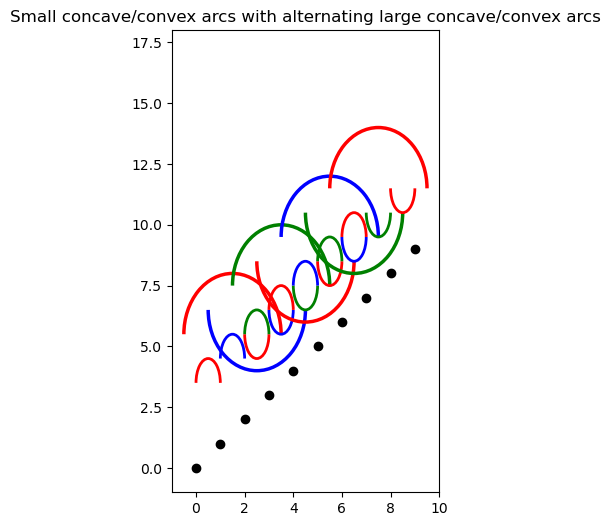

In [82]:
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

def plot_semicircle_groups(n=10):
    xs = list(range(n))
    ys = xs[:]  # identity

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(xs, ys, 'ko')

    colors = ["red", "blue", "green"]

    # Heights / offsets
    small_height = 2.0
    vertical_offset = 3.0
    big_height = 5.0

    for i in range(n - 3):
        color = colors[i % len(colors)]

        # INPUT pair
        x0, x1 = xs[i], xs[i+1]
        xm_in = (x0 + x1) / 2
        ym_in = (ys[i] + ys[i+1]) / 2 + vertical_offset

        # OUTPUT pair
        y0, y1 = xs[i+2], xs[i+3]
        xm_out = (y0 + y1) / 2
        ym_out = (ys[i+2] + ys[i+3]) / 2 + vertical_offset

        # -------------------
        # SMALL SEMICIRCLES
        # -------------------

        # Input (concave upward)
        arc_in = Arc(
            (xm_in, ym_in),
            width=(x1 - x0),
            height=small_height,
            theta1=0, theta2=180,
            lw=2, color=color
        )
        ax.add_patch(arc_in)

        # Output (convex downward)
        arc_out = Arc(
            (xm_out, ym_out),
            width=(y1 - y0),
            height=small_height,
            theta1=180, theta2=360,
            lw=2, color=color
        )
        ax.add_patch(arc_out)

        # -------------------
        # BIG ARC BETWEEN THEM
        # -------------------

        big_center_x = (xm_in + xm_out) / 2
        big_center_y = (ym_in + ym_out) / 2 + 1.0

        span = abs(xm_out - xm_in) * 2.0

        if i % 2 == 0:
            # Even index → big concave (upward)
            big_arc = Arc(
                (big_center_x, big_center_y),
                width=span,
                height=big_height,
                theta1=0, theta2=180,
                lw=2.5, color=color
            )
        else:
            # Odd index → big convex (downward)
            big_arc = Arc(
                (big_center_x, big_center_y),
                width=span,
                height=big_height,
                theta1=180, theta2=360,
                lw=2.5, color=color
            )

        ax.add_patch(big_arc)

    ax.set_xlim(-1, n)
    ax.set_ylim(-1, n + 8)
    ax.set_aspect("equal")
    ax.set_title("Small concave/convex arcs with alternating large concave/convex arcs")
    plt.show()


# Example
plot_semicircle_groups(10)


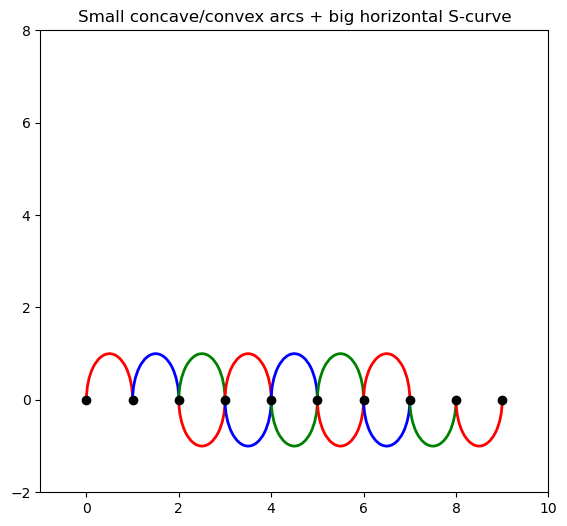

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
from matplotlib.path import Path
import matplotlib.patches as patches

def plot_sigmoid_groups(n=10):
    xs = np.arange(n)
    ys = np.zeros(n)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(xs, ys, 'ko')

    colors = ["red", "blue", "green"]

    small_height = 2
    vertical_offset = 0
    s_height = 3.5   # amplitude of S-curve

    for i in range(n - 3):
        color = colors[i % len(colors)]

        # Input pair (i, i+1)
        x0, x1 = xs[i], xs[i+1]
        xm_in = (x0 + x1) / 2
        ym_in = vertical_offset

        # Output pair (i+2, i+3)
        y0, y1 = xs[i+2], xs[i+3]
        xm_out = (y0 + y1) / 2
        ym_out = vertical_offset

        # -----------------------------------
        # SMALL SEMICIRCLES (concave / convex)
        # -----------------------------------

        # Small concave (input)
        arc_in = Arc(
            (xm_in, ym_in),
            width=(x1 - x0),
            height=small_height,
            theta1=0, theta2=180,
            lw=2, color=color
        )
        ax.add_patch(arc_in)

        # Small convex (output)
        arc_out = Arc(
            (xm_out, ym_out),
            width=(y1 - y0),
            height=small_height,
            theta1=180, theta2=360,
            lw=2, color=color
        )
        ax.add_patch(arc_out)


    ax.set_xlim(-1, n)
    ax.set_ylim(-2, 8)
    ax.set_aspect("equal")
    ax.set_title("Small concave/convex arcs + big horizontal S-curve")
    plt.show()


# Example
plot_sigmoid_groups(10)


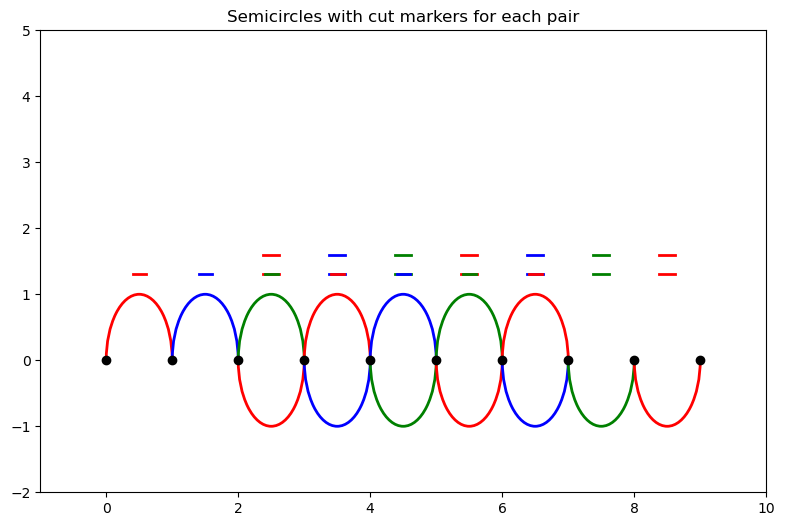

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

def plot_sigmoid_groups(n=10):
    xs = np.arange(n)
    ys = np.zeros(n)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(xs, ys, 'ko')

    colors = ["red", "blue", "green"]

    small_height = 2
    vertical_offset = 0

    for i in range(n - 3):
        color = colors[i % len(colors)]

        # Input pair (i, i+1)
        x0, x1 = xs[i], xs[i+1]
        xm_in = (x0 + x1) / 2
        ym_in = vertical_offset

        # Output pair (i+2, i+3)
        y0, y1 = xs[i+2], xs[i+3]
        xm_out = (y0 + y1) / 2
        ym_out = vertical_offset

        # -----------------------------------
        # SMALL SEMICIRCLES (concave / convex)
        # -----------------------------------

        # Small concave (input)
        arc_in = Arc(
            (xm_in, ym_in),
            width=(x1 - x0),
            height=small_height,
            theta1=0, theta2=180,
            lw=2, color=color
        )
        ax.add_patch(arc_in)

        # Small convex (output)
        arc_out = Arc(
            (xm_out, ym_out),
            width=(y1 - y0),
            height=small_height,
            theta1=180, theta2=360,
            lw=2, color=color
        )
        ax.add_patch(arc_out)

        # ----------------------------
        # CUT MARKS ABOVE EACH PAIR
        # ----------------------------

        # Input pair → 1 cut
        ax.plot(
            [xm_in - 0.1, xm_in + 0.1],
            [ym_in + small_height/2 + 0.3]*2,
            color=color, lw=2
        )

        # Output pair → 2 cuts
        ax.plot(
            [xm_out - 0.12, xm_out + 0.12],
            [ym_out + small_height/2 + 0.3]*2,
            color=color, lw=2
        )
        ax.plot(
            [xm_out - 0.12, xm_out + 0.12],
            [ym_out + small_height/2 + 0.6]*2,
            color=color, lw=2
        )

    ax.set_xlim(-1, n)
    ax.set_ylim(-2, 5)
    ax.set_aspect("equal")
    ax.set_title("Semicircles with cut markers for each pair")
    plt.show()

plot_sigmoid_groups(10)


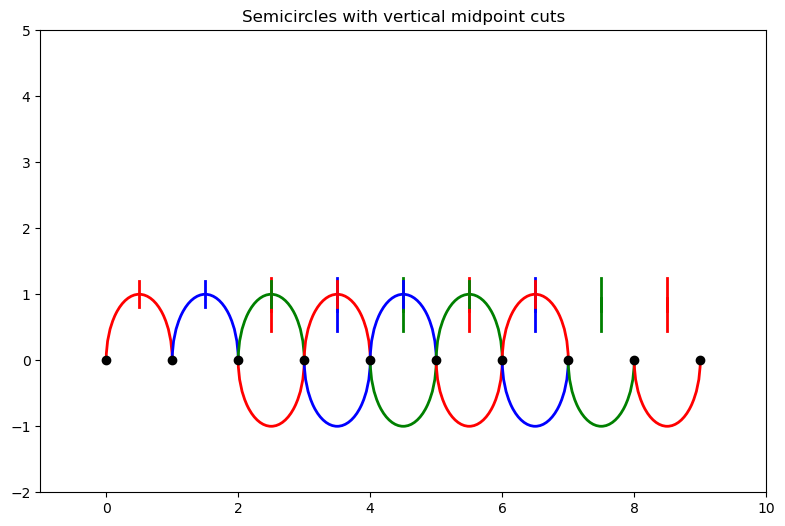

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

def plot_sigmoid_groups(n=10):
    xs = np.arange(n)
    ys = np.zeros(n)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(xs, ys, 'ko')

    colors = ["red", "blue", "green"]

    small_height = 2
    vertical_offset = 0

    for i in range(n - 3):
        color = colors[i % len(colors)]

        # Input pair (i, i+1)
        x0, x1 = xs[i], xs[i+1]
        xm_in = (x0 + x1) / 2
        ym_in = vertical_offset

        # Output pair (i+2, i+3)
        y0, y1 = xs[i+2], xs[i+3]
        xm_out = (y0 + y1) / 2
        ym_out = vertical_offset

        # -----------------------------------
        # SMALL SEMICIRCLES
        # -----------------------------------

        # Concave (input)
        arc_in = Arc(
            (xm_in, ym_in),
            width=(x1 - x0),
            height=small_height,
            theta1=0, theta2=180,
            lw=2, color=color
        )
        ax.add_patch(arc_in)

        # Convex (output)
        arc_out = Arc(
            (xm_out, ym_out),
            width=(y1 - y0),
            height=small_height,
            theta1=180, theta2=360,
            lw=2, color=color
        )
        ax.add_patch(arc_out)

        # -----------------------------------
        # VERTICAL CUTS AT SEMICIRCLE MIDPOINTS
        # -----------------------------------

        # Top of semicircle = center_y + height/2
        in_top_y = ym_in + small_height/2
        out_top_y = ym_out + small_height/2

        # Input pair → 1 cut
        ax.plot(
            [xm_in, xm_in],
            [in_top_y - 0.2, in_top_y + 0.2],
            color=color, lw=2
        )

        # Output pair → 2 cuts
        ax.plot(
            [xm_out, xm_out],
            [out_top_y - 0.25, out_top_y + 0.25],
            color=color, lw=2
        )
        ax.plot(
            [xm_out, xm_out],
            [out_top_y - 0.55, out_top_y - 0.05],
            color=color, lw=2
        )

    ax.set_xlim(-1, n)
    ax.set_ylim(-2, 5)
    ax.set_aspect("equal")
    ax.set_title("Semicircles with vertical midpoint cuts")
    plt.show()

plot_sigmoid_groups(10)


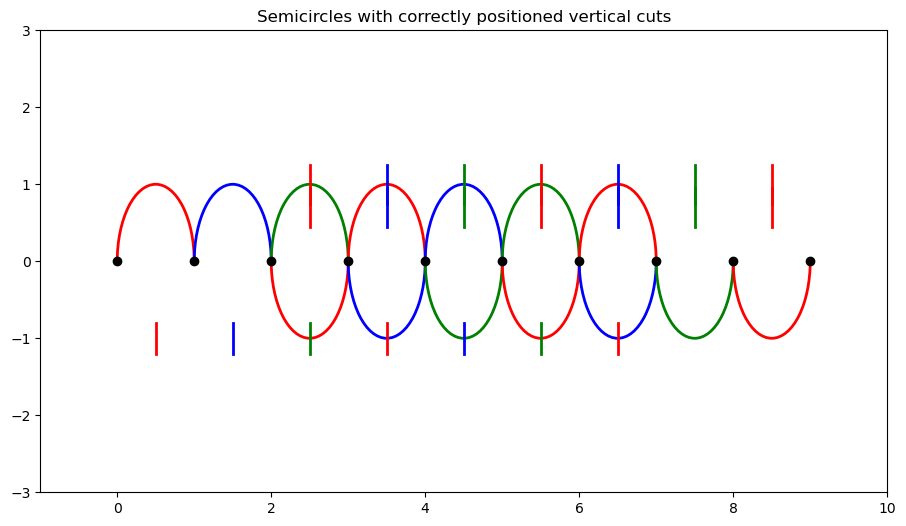

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

def plot_sigmoid_groups(n=10):
    xs = np.arange(n)
    ys = np.zeros(n)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(xs, ys, 'ko')

    colors = ["red", "blue", "green"]

    small_height = 2
    vertical_offset = 0

    for i in range(n - 3):
        color = colors[i % len(colors)]

        # Input pair (concave)
        x0, x1 = xs[i], xs[i+1]
        xm_in = (x0 + x1) / 2
        ym_in = vertical_offset

        # Output pair (convex)
        y0, y1 = xs[i+2], xs[i+3]
        xm_out = (y0 + y1) / 2
        ym_out = vertical_offset

        # -----------------------------------
        # SMALL SEMICIRCLES
        # -----------------------------------

        # Input concave (opens downward → midpoint lower)
        arc_in = Arc(
            (xm_in, ym_in),
            width=(x1 - x0),
            height=small_height,
            theta1=0, theta2=180,
            lw=2, color=color
        )
        ax.add_patch(arc_in)

        # Output convex (opens upward → midpoint upper)
        arc_out = Arc(
            (xm_out, ym_out),
            width=(y1 - y0),
            height=small_height,
            theta1=180, theta2=360,
            lw=2, color=color
        )
        ax.add_patch(arc_out)

        # -----------------------------------
        # CORRECTED MIDPOINT CUTS
        # -----------------------------------

        # Concave arc midpoint (DOWNWARD)
        in_mid_y = ym_in - small_height/2

        # Convex arc midpoint (UPWARD)
        out_mid_y = ym_out + small_height/2

        # Input pair → 1 cut
        ax.plot(
            [xm_in, xm_in],
            [in_mid_y - 0.2, in_mid_y + 0.2],
            color=color, lw=2
        )

        # Output pair → 2 cuts
        ax.plot(
            [xm_out, xm_out],
            [out_mid_y - 0.25, out_mid_y + 0.25],
            color=color, lw=2
        )
        ax.plot(
            [xm_out, xm_out],
            [out_mid_y - 0.55, out_mid_y - 0.05],
            color=color, lw=2
        )

    ax.set_xlim(-1, n)
    ax.set_ylim(-3, 3)
    ax.set_aspect("equal")
    ax.set_title("Semicircles with correctly positioned vertical cuts")
    plt.show()

plot_sigmoid_groups(10)


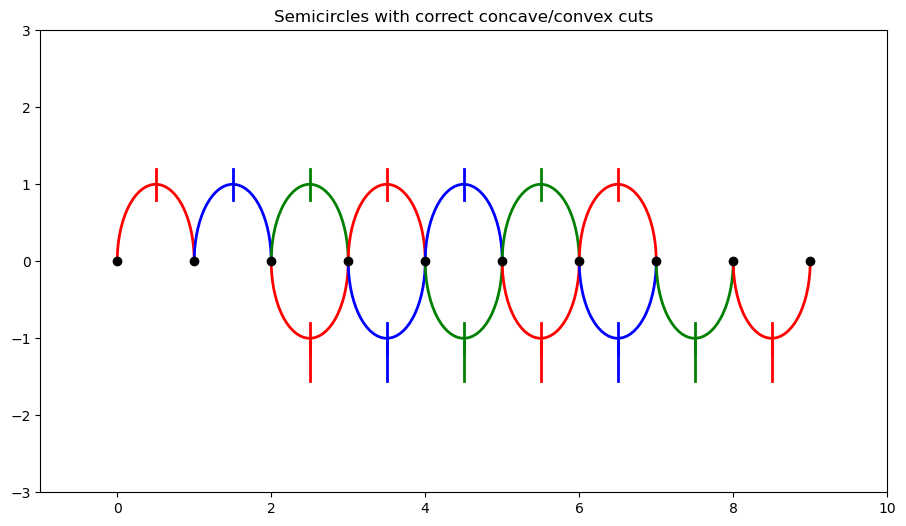

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

def plot_sigmoid_groups(n=10):
    xs = np.arange(n)
    ys = np.zeros(n)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(xs, ys, 'ko')

    colors = ["red", "blue", "green"]

    small_height = 2
    vertical_offset = 0

    for i in range(n - 3):
        color = colors[i % len(colors)]

        # Input pair (concave UPWARD)
        x0, x1 = xs[i], xs[i+1]
        xm_in = (x0 + x1) / 2
        ym_in = vertical_offset

        # Output pair (convex DOWNWARD)
        y0, y1 = xs[i+2], xs[i+3]
        xm_out = (y0 + y1) / 2
        ym_out = vertical_offset

        # -----------------------------------
        # SEMICIRCLES
        # -----------------------------------

        # Concave upward 0→180
        arc_in = Arc(
            (xm_in, ym_in),
            width=(x1 - x0),
            height=small_height,
            theta1=0, theta2=180,
            lw=2, color=color
        )
        ax.add_patch(arc_in)

        # Convex downward 180→360
        arc_out = Arc(
            (xm_out, ym_out),
            width=(y1 - y0),
            height=small_height,
            theta1=180, theta2=360,
            lw=2, color=color
        )
        ax.add_patch(arc_out)

        # -----------------------------------
        # CORRECTED CUT POSITIONS
        # -----------------------------------

        # Concave (upward arc) → cut ABOVE
        in_mid_y = ym_in + small_height / 2

        # Convex (downward arc) → cuts BELOW
        out_mid_y = ym_out - small_height / 2

        # 1 cut for input
        ax.plot(
            [xm_in, xm_in],
            [in_mid_y - 0.2, in_mid_y + 0.2],
            color=color, lw=2
        )

        # 2 cuts for output
        ax.plot(
            [xm_out, xm_out],
            [out_mid_y - 0.2, out_mid_y + 0.2],
            color=color, lw=2
        )
        ax.plot(
            [xm_out, xm_out],
            [out_mid_y - 0.55, out_mid_y - 0.05],
            color=color, lw=2
        )

    ax.set_xlim(-1, n)
    ax.set_ylim(-3, 3)
    ax.set_aspect("equal")
    ax.set_title("Semicircles with correct concave/convex cuts")
    plt.show()

plot_sigmoid_groups(10)


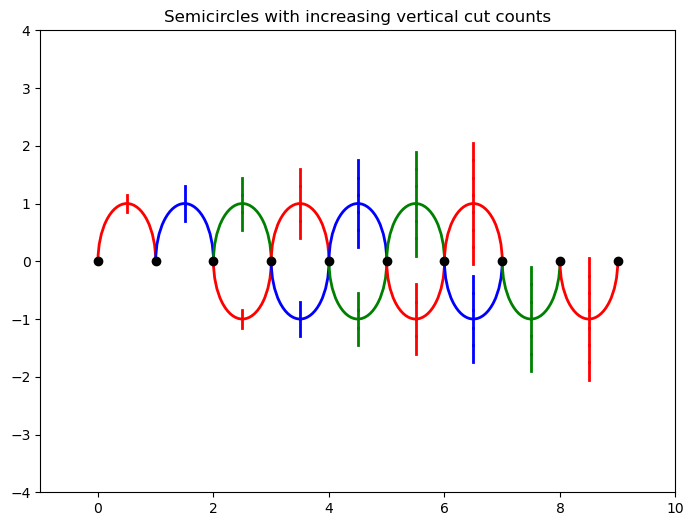

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

def plot_sigmoid_groups(n=10):
    xs = np.arange(n)
    ys = np.zeros(n)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(xs, ys, 'ko')

    colors = ["red", "blue", "green"]

    small_height = 2
    vertical_offset = 0
    cut_span = 0.3   # total height of cut cluster
    cut_gap  = 0.3   # spacing between cuts

    for i in range(n - 3):
        color = colors[i % len(colors)]

        # Input: (i, i+1), upward concave
        x0, x1 = xs[i], xs[i+1]
        xm_in = (x0 + x1) / 2
        ym_in = vertical_offset

        # Output: (i+2, i+3), downward convex
        y0, y1 = xs[i+2], xs[i+3]
        xm_out = (y0 + y1) / 2
        ym_out = vertical_offset

        # -----------------------------------
        # SEMICIRCLES
        # -----------------------------------

        # Concave upward
        arc_in = Arc(
            (xm_in, ym_in),
            width=(x1 - x0),
            height=small_height,
            theta1=0, theta2=180,
            lw=2, color=color
        )
        ax.add_patch(arc_in)

        # Convex downward
        arc_out = Arc(
            (xm_out, ym_out),
            width=(y1 - y0),
            height=small_height,
            theta1=180, theta2=360,
            lw=2, color=color
        )
        ax.add_patch(arc_out)

        # -----------------------------------
        # CUT POSITION CENTERLINES
        # -----------------------------------

        # Concave midpoint ABOVE
        in_mid_y = ym_in + small_height / 2

        # Convex midpoint BELOW
        out_mid_y = ym_out - small_height / 2

        # -----------------------------------
        # VARIABLE NUMBER OF CUTS
        # -----------------------------------

        num_cuts_in  = i + 1         # input: 1,2,3,...
        num_cuts_out = i + 1         # output: same growth

        # ----- Input cuts (above arc, close together) -----
        for k in range(num_cuts_in):
            offset = (k - (num_cuts_in - 1)/2) * cut_gap
            ax.plot(
                [xm_in, xm_in],
                [in_mid_y + offset - cut_span/2,
                 in_mid_y + offset + cut_span/2],
                color=color, lw=2
            )

        # ----- Output cuts (below arc, close together) -----
        for k in range(num_cuts_out):
            offset = (k - (num_cuts_out - 1)/2) * cut_gap
            ax.plot(
                [xm_out, xm_out],
                [out_mid_y + offset - cut_span/2,
                 out_mid_y + offset + cut_span/2],
                color=color, lw=2
            )

    ax.set_xlim(-1, n)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
    ax.set_title("Semicircles with increasing vertical cut counts")
    plt.show()

plot_sigmoid_groups(10)


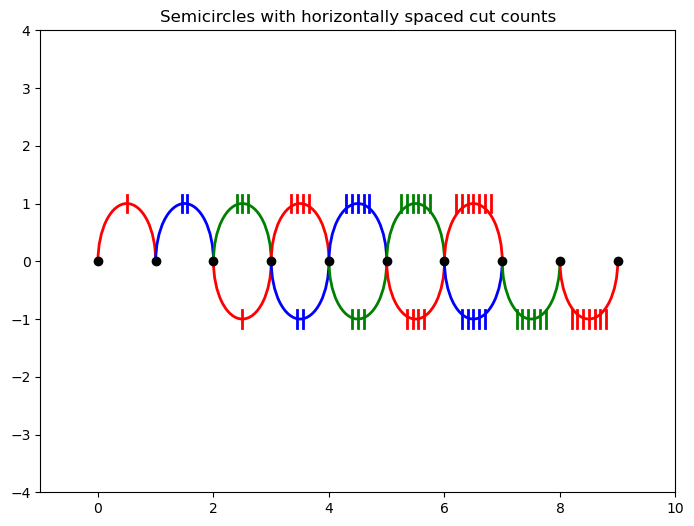

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

def plot_sigmoid_groups(n=10):
    xs = np.arange(n)
    ys = np.zeros(n)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(xs, ys, 'ko')

    colors = ["red", "blue", "green"]

    small_height = 2
    vertical_offset = 0
    cut_span = 0.3     # height of each cut
    cut_gap  = 0.1     # horizontal spacing between cuts

    for i in range(n - 3):
        color = colors[i % len(colors)]

        # input semicircle (concave up)
        x0, x1 = xs[i], xs[i+1]
        xm_in = (x0 + x1) / 2
        ym_in = vertical_offset

        # output semicircle (convex down)
        y0, y1 = xs[i+2], xs[i+3]
        xm_out = (y0 + y1) / 2
        ym_out = vertical_offset

        # ----------------------------
        # SEMICIRCLES
        # ----------------------------

        arc_in = Arc(
            (xm_in, ym_in),
            width=(x1 - x0),
            height=small_height,
            theta1=0, theta2=180,
            lw=2, color=color
        )
        ax.add_patch(arc_in)

        arc_out = Arc(
            (xm_out, ym_out),
            width=(y1 - y0),
            height=small_height,
            theta1=180, theta2=360,
            lw=2, color=color
        )
        ax.add_patch(arc_out)

        # ----------------------------
        # CUT ANCHOR HEIGHTS
        # ----------------------------

        in_mid_y  = ym_in + small_height/2     # above
        out_mid_y = ym_out - small_height/2    # below

        num_cuts = i + 1    # 1, 2, 3, ...

        # ----------------------------
        # INPUT CUTS (horizontal series)
        # ----------------------------

        for k in range(num_cuts):
            # horizontal displacement for each cut
            x_shift = (k - (num_cuts - 1)/2) * cut_gap
            x_pos = xm_in + x_shift

            ax.plot(
                [x_pos, x_pos],
                [in_mid_y - cut_span/2, in_mid_y + cut_span/2],
                lw=2, color=color
            )

        # ----------------------------
        # OUTPUT CUTS (horizontal series)
        # ----------------------------

        for k in range(num_cuts):
            x_shift = (k - (num_cuts - 1)/2) * cut_gap
            x_pos = xm_out + x_shift

            ax.plot(
                [x_pos, x_pos],
                [out_mid_y - cut_span/2, out_mid_y + cut_span/2],
                lw=2, color=color
            )

    ax.set_xlim(-1, n)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
    ax.set_title("Semicircles with horizontally spaced cut counts")
    plt.show()

plot_sigmoid_groups(10)


# MIMO-MULTIVARIATE-ALL_FOR_ALL

In [ ]:
# split a multivariate sequence into samples
def split_sequences(sequences, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[end_ix:out_end_ix, :]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [282]:
# choose a number of time steps
n_steps_in, n_steps_out = 20, 20
# convert into input/output
X, y = split_sequences(test_scaled, n_steps_in, n_steps_out)

In [ ]:
for i in range(len(X)):
        # ---------------------------

        # Inputs: concave upward
    print(X[i], y[i])

[[0.34753992 0.45374765 0.59827905]
 [0.40194509 0.43482175 0.46849719]
 [0.39118066 0.39351481 0.37643233]
 [0.32763923 0.31266264 0.3403495 ]
 [0.19736059 0.18552764 0.43955911]
 [0.07758895 0.19365707 0.7267321 ]
 [0.18592066 0.41147511 0.77894921]
 [0.35911786 0.47644428 0.61225437]
 [0.43018844 0.46245787 0.47006284]
 [0.43622611 0.43790884 0.36393055]
 [0.40500213 0.39210149 0.29144302]
 [0.32153987 0.29063314 0.27855921]
 [0.15351502 0.13006804 0.44936847]
 [0.04144834 0.22062651 0.82369322]
 [0.23956545 0.48309182 0.77035246]
 [0.4258563  0.51457162 0.57601581]
 [0.49293609 0.50798839 0.43869853]
 [0.52159613 0.52153887 0.33867037]
 [0.56172516 0.56734414 0.27199902]
 [0.6526745  0.67645505 0.26849431]] [[0.83212894 0.8422737  0.46947661]
 [0.92744307 0.71141413 0.85103459]
 [0.70476579 0.45540559 0.75708462]
 [0.52384983 0.43417559 0.56367645]
 [0.45957853 0.4370129  0.43099192]
 [0.42465117 0.41291829 0.33723808]
 [0.36613946 0.34491714 0.28736964]
 [0.24064657 0.20612173 0.3

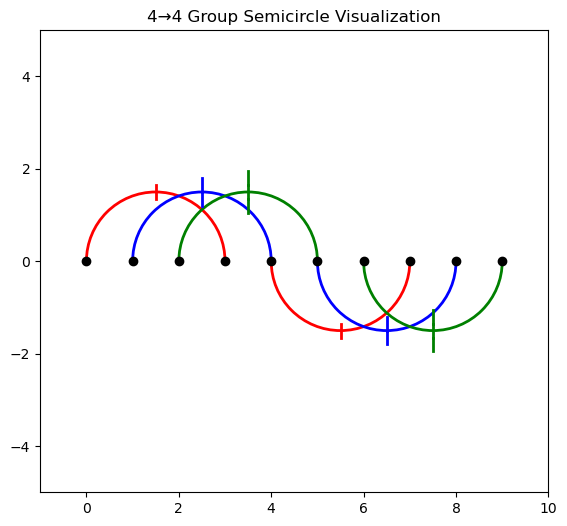

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

def plot_sigmoid_groups(n=10):
    xs = np.arange(n)
    ys = np.zeros(n)

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(xs, ys, 'ko')

    colors = ["red", "blue", "green"]

    small_height = 3
    cut_span = 0.3
    cut_gap  = 0.3

    window = 4   # now each block uses 4 inputs → 4 outputs

    # Maximum block index: we need i+window*2 ≤ n
    max_i = n - 2 * window

    for i in range(max_i + 1):
        color = colors[i % len(colors)]

        # Inputs: i, i+1, i+2, i+3
        x_inputs = xs[i:i+window]
        left_in  = x_inputs[0]
        right_in = x_inputs[-1]
        xm_in = (left_in + right_in) / 2
        ym_in = 0

        # Outputs: i+4, i+5, i+6, i+7
        x_outputs = xs[i+window:i+2*window]
        left_out  = x_outputs[0]
        right_out = x_outputs[-1]
        xm_out = (left_out + right_out) / 2
        ym_out = 0

        # ---------------------------
        # LARGE SEMICIRCLES
        # ---------------------------

        # Inputs: concave upward
        arc_in = Arc(
            (xm_in, ym_in),
            width=(right_in - left_in),
            height=small_height,
            theta1=0, theta2=180,
            lw=2, color=color
        )
        ax.add_patch(arc_in)

        # Outputs: convex downward
        arc_out = Arc(
            (xm_out, ym_out),
            width=(right_out - left_out),
            height=small_height,
            theta1=180, theta2=360,
            lw=2, color=color
        )
        ax.add_patch(arc_out)

        # ---------------------------
        # CUT POSITIONS
        # ---------------------------

        in_mid_y  = ym_in + small_height/2     # concave → above
        out_mid_y = ym_out - small_height/2    # convex → below

        num_cuts = i + 1  # cut count grows per block

        # Input cuts (above)
        for k in range(num_cuts):
            offset = (k - (num_cuts - 1)/2) * cut_gap
            ax.plot(
                [xm_in, xm_in],
                [in_mid_y + offset - cut_span/2,
                 in_mid_y + offset + cut_span/2],
                color=color, lw=2
            )

        # Output cuts (below)
        for k in range(num_cuts):
            offset = (k - (num_cuts - 1)/2) * cut_gap
            ax.plot(
                [xm_out, xm_out],
                [out_mid_y + offset - cut_span/2,
                 out_mid_y + offset + cut_span/2],
                color=color, lw=2
            )import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

def plot_sigmoid_groups(n=10):
    xs = np.arange(n)
    ys = np.zeros(n)

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(xs, ys, 'ko')

    colors = ["red", "blue", "green"]

    small_height = 3
    cut_span = 0.3
    cut_gap  = 0.3

    window = 4   # now each block uses 4 inputs → 4 outputs

    # Maximum block index: we need i+window*2 ≤ n
    max_i = n - 2 * window

    for i in range(max_i + 1):
        color = colors[i % len(colors)]

        # Inputs: i, i+1, i+2, i+3
        x_inputs = xs[i:i+window]
        left_in  = x_inputs[0]
        # ---------------------------

        # Inputs: concave upward
        right_in = x_inputs[-1]
        xm_in = (left_in + right_in) / 2
        ym_in = 0

        # Outputs: i+4, i+5, i+6, i+7
        x_outputs = xs[i+window:i+2*window]
        left_out  = x_outputs[0]
        right_out = x_outputs[-1]
        xm_out = (left_out + right_out) / 2
        ym_out = 0

        # ---------------------------
        # LARGE SEMICIRCLES
        # ---------------------------

        # Inputs: concave upward
        arc_in = Arc(
            (xm_in, ym_in),
            width=(right_in - left_in),
            height=small_height,
            theta1=0, theta2=180,
            lw=2, color=color
        )
        ax.add_patch(arc_in)

        # Outputs: convex downward
        arc_out = Arc(
            (xm_out, ym_out),
            width=(right_out - left_out),
            height=small_height,
            theta1=180, theta2=360,
            lw=2, color=color
        )
        ax.add_patch(arc_out)

        # ---------------------------
        # CUT POSITIONS
        # ---------------------------

        in_mid_y  = ym_in + small_height/2     # concave → above
        out_mid_y = ym_out - small_height/2    # convex → below

        num_cuts = i + 1  # cut count grows per block

        # Input cuts (above)
        for k in range(num_cuts):
            offset = (k - (num_cuts - 1)/2) * cut_gap
            ax.plot(
                [xm_in, xm_in],
                [in_mid_y + offset - cut_span/2,
                 in_mid_y + offset + cut_span/2],
                color=color, lw=2
            )

        # Output cuts (below)
        for k in range(num_cuts):
            offset = (k - (num_cuts - 1)/2) * cut_gap
            ax.plot(
                [xm_out, xm_out],
                [out_mid_y + offset - cut_span/2,
                 out_mid_y + offset + cut_span/2],
                color=color, lw=2
            )

    ax.set_xlim(-1, n)
    ax.set_ylim(-5, 5)
    ax.set_aspect("equal")
    ax.set_title("4→4 Group Semicircle Visualization")
    plt.show()


plot_sigmoid_groups(10)

    ax.set_xlim(-1, n)
    ax.set_ylim(-5, 5)
    ax.set_aspect("equal")
    ax.set_title("4→4 Group Semicircle Visualization")
    plt.show()


plot_sigmoid_groups(10)


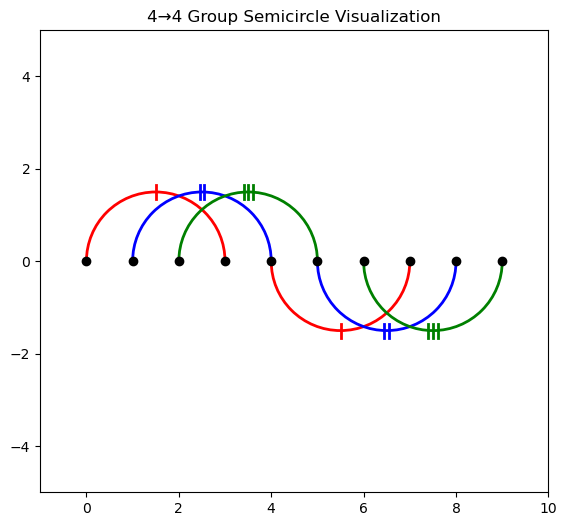

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

def plot_sigmoid_groups(n=10):
    xs = np.arange(n)
    ys = np.zeros(n)

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(xs, ys, 'ko')

    colors = ["red", "blue", "green"]

    small_height = 3
    cut_span = 0.3
    cut_gap  = 0.1   # now used horizontally

    window = 4

    max_i = n - 2 * window

    for i in range(max_i + 1):
        color = colors[i % len(colors)]

        x_inputs = xs[i:i+window]
        left_in  = x_inputs[0]
        right_in = x_inputs[-1]
        xm_in = (left_in + right_in) / 2
        ym_in = 0

        x_outputs = xs[i+window:i+2*window]
        left_out  = x_outputs[0]
        right_out = x_outputs[-1]
        xm_out = (left_out + right_out) / 2
        ym_out = 0

        # semicircles
        arc_in = Arc((xm_in, ym_in), width=(right_in - left_in),
                     height=small_height, theta1=0, theta2=180,
                     lw=2, color=color)
        ax.add_patch(arc_in)

        arc_out = Arc((xm_out, ym_out), width=(right_out - left_out),
                      height=small_height, theta1=180, theta2=360,
                      lw=2, color=color)
        ax.add_patch(arc_out)

        # cut anchors
        in_mid_y  = ym_in + small_height/2     # concave → above
        out_mid_y = ym_out - small_height/2    # convex → below

        # number of cuts = i+1
        num_cuts = i + 1

        # ----------------------------------------------------
        # INPUT CUTS (above) → horizontally spaced, |, ||, |||
        # ----------------------------------------------------
        for k in range(num_cuts):
            x_shift = (k - (num_cuts - 1)/2) * cut_gap
            x_pos = xm_in + x_shift

            ax.plot(
                [x_pos, x_pos],
                [in_mid_y - cut_span/2, in_mid_y + cut_span/2],
                color=color, lw=2
            )

        # ----------------------------------------------------
        # OUTPUT CUTS (below) → same pattern
        # ----------------------------------------------------
        for k in range(num_cuts):
            x_shift = (k - (num_cuts - 1)/2) * cut_gap
            x_pos = xm_out + x_shift

            ax.plot(
                [x_pos, x_pos],
                [out_mid_y - cut_span/2, out_mid_y + cut_span/2],
                color=color, lw=2
            )

    ax.set_xlim(-1, n)
    ax.set_ylim(-5, 5)
    ax.set_aspect("equal")
    ax.set_title("4→4 Group Semicircle Visualization")
    plt.show()


plot_sigmoid_groups(10)


# DIRMO-MULTIVARIATE-ALL_FOR_ALL
Dividir el horizonte $H$ en bloques $B$ de modo que $H/B = N$, y entrenar $N$ modelos, cada uno encargado de predecir $B$ pasos consecutivos. 

In [68]:
# split a multivariate sequence into samples
def split_sequences_v1(sequences, n_steps_in, n_steps_out, skip):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences)-skip:
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[skip + end_ix:out_end_ix + skip , :]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [69]:
n_steps_in = 1
n_steps_out = 2
horizon = 4
skip = n_steps_out
datasets = {}
for i in range(0, horizon, skip):
    X, y = split_sequences_v1(dataset, n_steps_in, n_steps_out, i)
    if len(X) == 0:
        raise ValueError(f"Insufficient data points for skip={i}.")
    #X = X.reshape((X.shape[0], X.shape[1], X.shape[2]))
    datasets[i] = (X, y)  # store as tuple

In [70]:
for i in datasets:
    print(i, end=' ')

0 2 

In [75]:
X, y = datasets[0]
print(X.shape)
print(y.shape)
for xi, yi in zip(X, y):
    print(xi,yi)

(8, 1, 3)
(8, 2, 3)
[[0 0 0]] [[1 2 3]
 [2 4 6]]
[[1 2 3]] [[2 4 6]
 [3 6 9]]
[[2 4 6]] [[ 3  6  9]
 [ 4  8 12]]
[[3 6 9]] [[ 4  8 12]
 [ 5 10 15]]
[[ 4  8 12]] [[ 5 10 15]
 [ 6 12 18]]
[[ 5 10 15]] [[ 6 12 18]
 [ 7 14 21]]
[[ 6 12 18]] [[ 7 14 21]
 [ 8 16 24]]
[[ 7 14 21]] [[ 8 16 24]
 [ 9 18 27]]


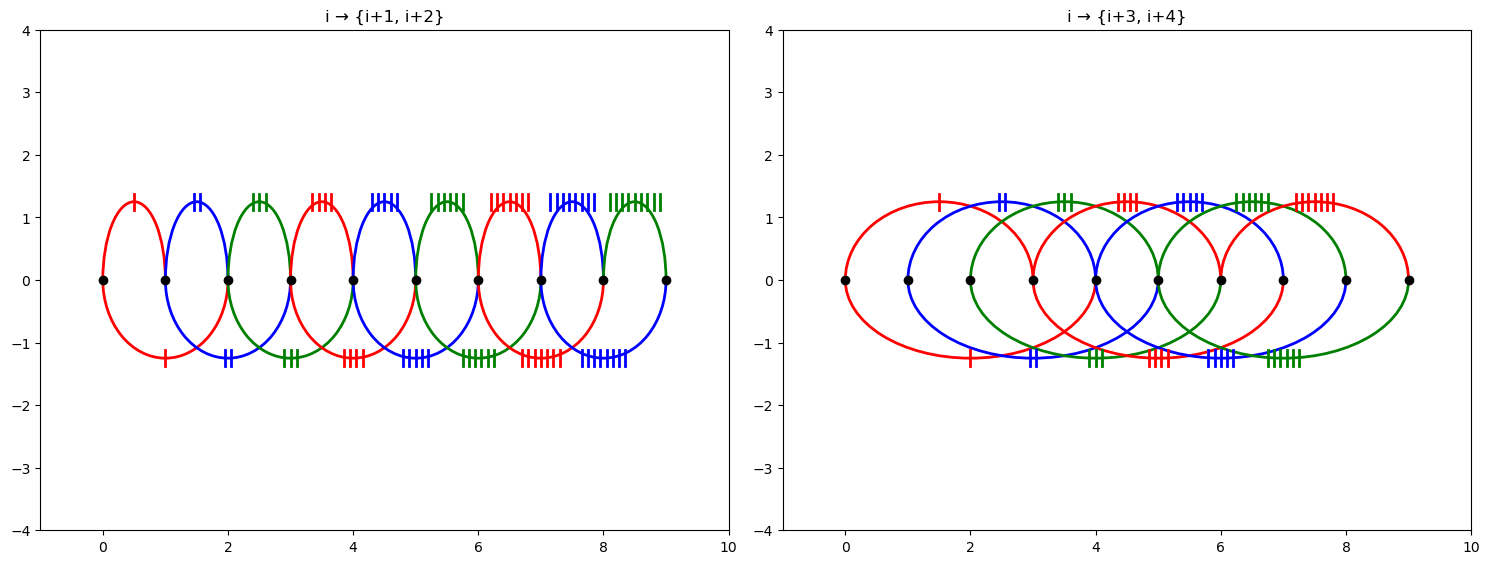

In [104]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

def draw_mapping(ax, n, offsets, title):
    xs = np.arange(n)
    ys = np.zeros(n)

    ax.plot(xs, ys, 'ko')

    colors = ["red", "blue", "green"]

    small_height = 2.5
    cut_span = 0.25
    cut_gap  = 0.1

    for i in range(n):
        color = colors[i % 3]

        targets = [i + off for off in offsets]
        targets = [t for t in targets if t < n]
        if not targets:
            continue

        # number of cuts grows
        num_cuts = i + 1

        # input point at x=i
        x_in = xs[i]
        y_in = 0

        # For each target → draw its own arc + cut cluster
        for idx, t in enumerate(targets):
            x_out = xs[t]

            # concave if first, convex if second
            upward = True if idx == 0 else False

            # arc center + width
            xm = (x_in + x_out) / 2
            w = abs(x_out - x_in)

            if upward:
                arc = Arc(
                    (xm, 0),
                    width=w,
                    height=small_height,
                    theta1=0,
                    theta2=180,
                    lw=2,
                    color=color
                )
                cut_y = small_height/2
            else:
                arc = Arc(
                    (xm, 0),
                    width=w,
                    height=small_height,
                    theta1=180,
                    theta2=360,
                    lw=2,
                    color=color
                )
                cut_y = -small_height/2

            ax.add_patch(arc)

            # cuts horizontally spaced
            for k in range(num_cuts):
                shift = (k - (num_cuts - 1)/2) * cut_gap
                x_pos = xm + shift

                ax.plot(
                    [x_pos, x_pos],
                    [cut_y - cut_span/2, cut_y + cut_span/2],
                    color=color, lw=2
                )

    ax.set_xlim(-1, n)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
    ax.set_title(title)


def plot_all():
    fig, axs = plt.subplots(1, 2, figsize=(15, 6))

    # PANEL 1: 0→1,2 / 1→2,3 / ... / 7→8,9
    draw_mapping(axs[0], n=10, offsets=[1, 2],
                 title="i → {i+1, i+2}")

    # PANEL 2: 0→3,4 / 1→4,5 / ... / 5→8,9
    draw_mapping(axs[1], n=10, offsets=[3, 4],
                 title="i → {i+3, i+4}")

    plt.tight_layout()
    plt.show()


plot_all()


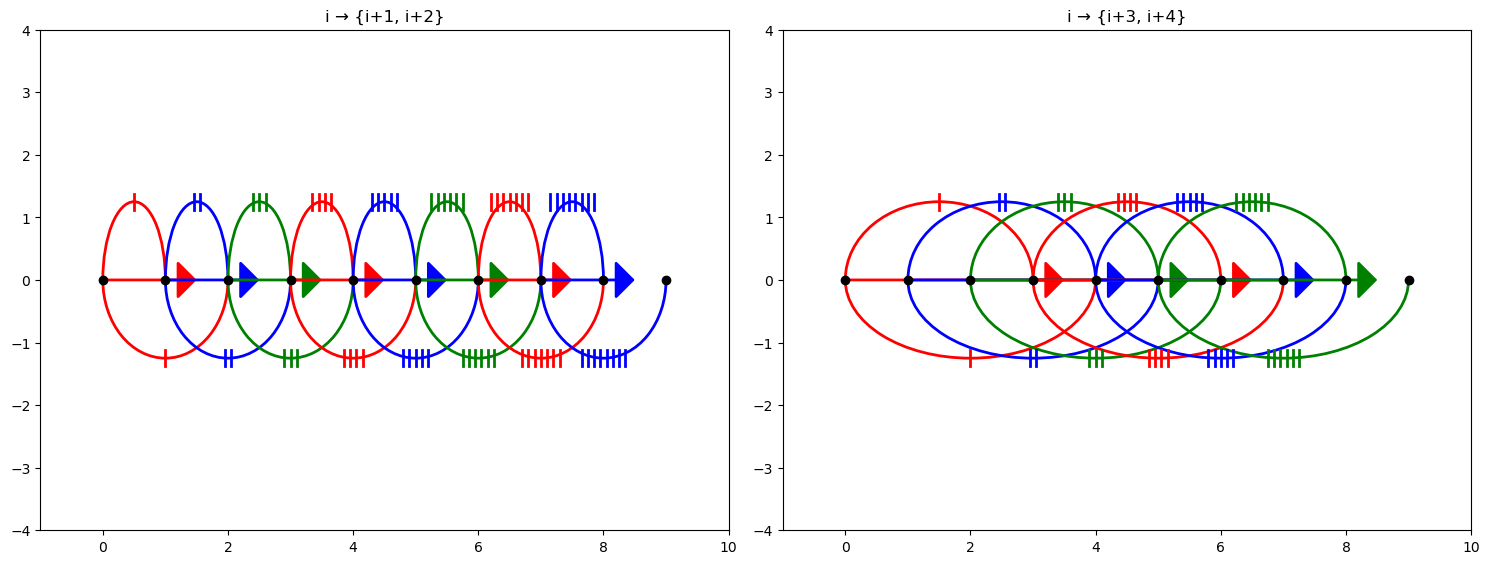

In [107]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, FancyArrowPatch

def draw_mapping(ax, n, offsets, title):
    xs = np.arange(n)
    ys = np.zeros(n)

    ax.plot(xs, ys, 'ko')

    colors = ["red", "blue", "green"]

    small_height = 2.5
    cut_span = 0.25
    cut_gap  = 0.1

    for i in range(n):
        color = colors[i % 3]

        # targets = {i+offset1, i+offset2}
        targets = [i + off for off in offsets]
        targets = [t for t in targets if t < n]
        if len(targets) < 2:
            continue

        t1, t2 = targets

        # center between target pair = arc anchor
        center_x = (xs[t1] + xs[t2]) / 2

        # -------------------------------------
        # ARROW (input → midpoint between outputs)
        # arrowhead is placed halfway (mutation_scale handles size)
        # -------------------------------------
        arrow = FancyArrowPatch(
            (xs[i], 0),
            (center_x, 0),
            arrowstyle='-|>',
            mutation_scale=12,
            color=color,
            lw=2,
            shrinkA=0,
            shrinkB=0,
            connectionstyle="arc3"
        )
        arrow.set_arrowstyle('-|>', head_length=1, head_width=1)

        # force arrowhead *in the middle*
        arrow.set_positions((xs[i], 0), (center_x, 0))
        arrow._mutation_scale = 12
        arrow._posA = (xs[i], 0)
        arrow._posB = ((xs[i] + center_x) / 2, 0)   # <--- midpoint head
        ax.add_patch(arrow)

        # Growing cut count
        num_cuts = i + 1

        # -------------------------------------
        # SEMICIRCLES FOR TARGETS
        # -------------------------------------

        # Upward concave for first target
        xm1 = (xs[i] + xs[t1]) / 2
        w1 = abs(xs[t1] - xs[i])
        arc1 = Arc((xm1, 0), width=w1, height=small_height,
                   theta1=0, theta2=180, lw=2, color=color)
        ax.add_patch(arc1)

        # Downward convex for second target
        xm2 = (xs[i] + xs[t2]) / 2
        w2 = abs(xs[t2] - xs[i])
        arc2 = Arc((xm2, 0), width=w2, height=small_height,
                   theta1=180, theta2=360, lw=2, color=color)
        ax.add_patch(arc2)

        # -------------------------------------
        # Cuts above (for concave) and below (for convex)
        # -------------------------------------
        y1 = small_height/2    # above
        y2 = -small_height/2   # below

        # concave cuts
        for k in range(num_cuts):
            shift = (k - (num_cuts - 1)/2) * cut_gap
            xx = xm1 + shift
            ax.plot([xx, xx], [y1-cut_span/2, y1+cut_span/2],
                    lw=2, color=color)

        # convex cuts
        for k in range(num_cuts):
            shift = (k - (num_cuts - 1)/2) * cut_gap
            xx = xm2 + shift
            ax.plot([xx, xx], [y2-cut_span/2, y2+cut_span/2],
                    lw=2, color=color)

    ax.set_xlim(-1, n)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
    ax.set_title(title)


def plot_all():
    fig, axs = plt.subplots(1, 2, figsize=(15, 6))

    draw_mapping(axs[0], 10, offsets=[1, 2], title="i → {i+1, i+2}")

    draw_mapping(axs[1], 10, offsets=[3, 4], title="i → {i+3, i+4}")

    plt.tight_layout()
    plt.show()


plot_all()


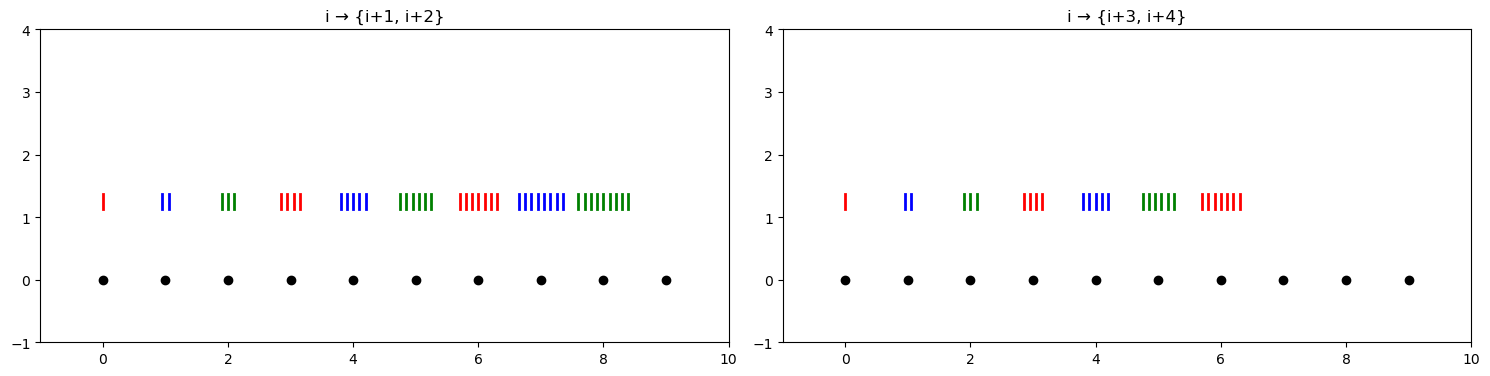

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def draw_mapping(ax, n, offsets, title):
    xs = np.arange(n)

    # Draw points
    ax.plot(xs, np.zeros(n), 'ko')

    colors = ["red", "blue", "green"]

    small_height = 2.5
    cut_span = 0.25
    cut_gap  = 0.1

    for i in range(n):
        color = colors[i % 3]

        targets = [i + off for off in offsets]
        targets = [t for t in targets if t < n]
        if not targets:
            continue

        # How many cuts to draw
        num_cuts = i + 1

        # Position of the source point
        x_in = xs[i]
        cut_y = small_height/2   # put cuts above

        # Draw cuts for the source only
        for k in range(num_cuts):
            shift = (k - (num_cuts - 1)/2) * cut_gap
            x_pos = x_in + shift
            ax.plot(
                [x_pos, x_pos],
                [cut_y - cut_span/2, cut_y + cut_span/2],
                color=color, lw=2
            )

    ax.set_xlim(-1, n)
    ax.set_ylim(-1, 4)
    ax.set_aspect("equal")
    ax.set_title(title)


def plot_all():
    fig, axs = plt.subplots(1, 2, figsize=(15, 6))

    draw_mapping(axs[0], n=10, offsets=[1, 2],
                 title="i → {i+1, i+2}")

    draw_mapping(axs[1], n=10, offsets=[3, 4],
                 title="i → {i+3, i+4}")

    plt.tight_layout()
    plt.show()

plot_all()


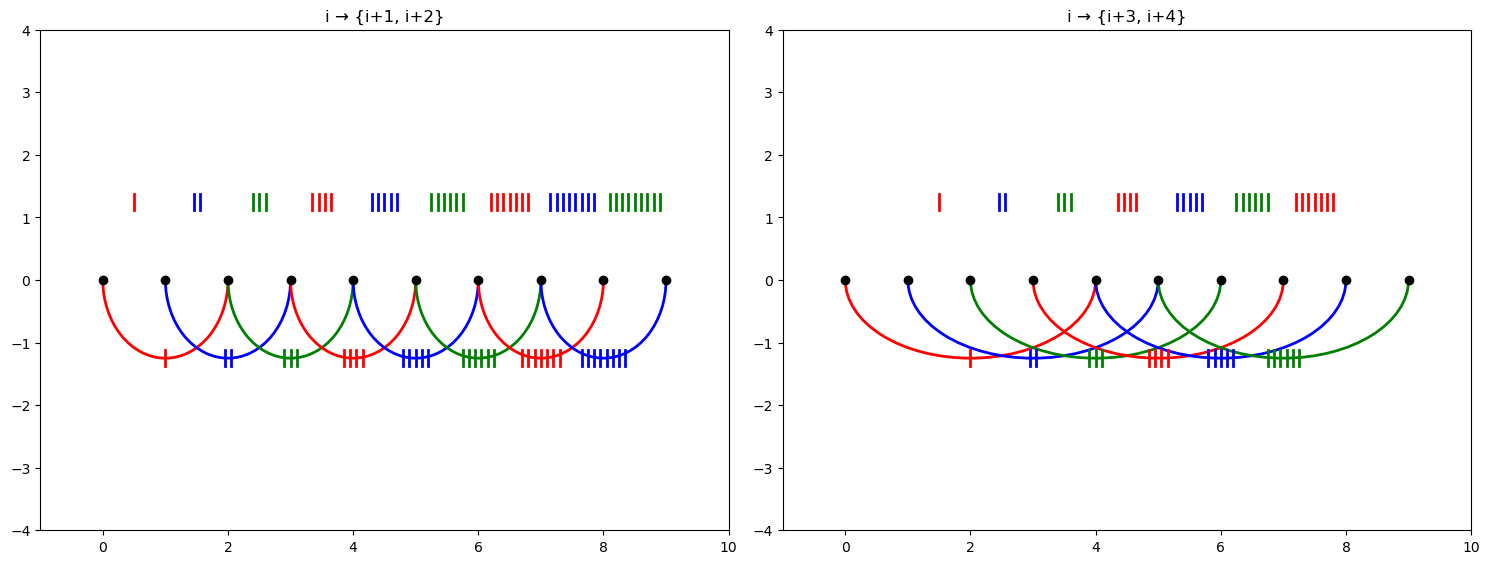

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

def draw_mapping(ax, n, offsets, title):
    xs = np.arange(n)
    ys = np.zeros(n)

    ax.plot(xs, ys, 'ko')

    colors = ["red", "blue", "green"]

    small_height = 2.5
    cut_span = 0.25
    cut_gap  = 0.1

    for i in range(n):
        color = colors[i % 3]

        targets = [i + off for off in offsets]
        targets = [t for t in targets if t < n]
        if not targets:
            continue

        # number of cuts grows with i
        num_cuts = i + 1

        x_in = xs[i]

        for idx, t in enumerate(targets):

            x_out = xs[t]
            xm = (x_in + x_out) / 2
            w = abs(x_out - x_in)

            upward = (idx == 0)    # first part of pair
            downward = not upward  # second part

            if upward:
                # FIRST part of pair: REMOVE arc, but keep cuts
                cut_y = small_height / 2

            else:
                # SECOND part: KEEP the downward arc
                arc = Arc(
                    (xm, 0),
                    width=w,
                    height=small_height,
                    theta1=180,
                    theta2=360,
                    lw=2,
                    color=color
                )
                ax.add_patch(arc)
                cut_y = -small_height / 2

            # Draw cuts for BOTH types
            for k in range(num_cuts):
                shift = (k - (num_cuts - 1)/2) * cut_gap
                x_pos = xm + shift

                ax.plot(
                    [x_pos, x_pos],
                    [cut_y - cut_span/2, cut_y + cut_span/2],
                    color=color,
                    lw=2
                )

    ax.set_xlim(-1, n)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
    ax.set_title(title)


def plot_all():
    fig, axs = plt.subplots(1, 2, figsize=(15, 6))

    # PANEL 1
    draw_mapping(
        axs[0],
        n=10,
        offsets=[1, 2],
        title="i → {i+1, i+2}"
    )

    # PANEL 2import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

def plot_sigmoid_groups(n=10):
    xs = np.arange(n)
    ys = np.zeros(n)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(xs, ys, 'ko')

    colors = ["red", "blue", "green"]

    small_height = 2
    vertical_offset = 0
    cut_span = 0.3     # height of each cut
    cut_gap  = 0.1     # horizontal spacing between cuts

    for i in range(n - 3):
        color = colors[i % len(colors)]

        # input semicircle (concave up)
        x0, x1 = xs[i], xs[i+1]
        xm_in = (x0 + x1) / 2
        ym_in = vertical_offset

        # output semicircle (convex down)
        y0, y1 = xs[i+2], xs[i+3]
        xm_out = (y0 + y1) / 2
        ym_out = vertical_offset

        # ----------------------------
        # SEMICIRCLES
        # ----------------------------

        arc_in = Arc(
            (xm_in, ym_in),
            width=(x1 - x0),
            height=small_height,
            theta1=0, theta2=180,
            lw=2, color=color
        )
        ax.add_patch(arc_in)

        arc_out = Arc(
            (xm_out, ym_out),
            width=(y1 - y0),
            height=small_height,
            theta1=180, theta2=360,
            lw=2, color=color
        )
        ax.add_patch(arc_out)

        # ----------------------------
        # CUT ANCHOR HEIGHTS
        # ----------------------------

        in_mid_y  = ym_in + small_height/2     # above
        out_mid_y = ym_out - small_height/2    # below
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

def plot_sigmoid_groups(n=10):
    xs = np.arange(n)
    ys = np.zeros(n)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(xs, ys, 'ko')

    colors = ["red", "blue", "green"]

    small_height = 2
    vertical_offset = 0
    cut_span = 0.3     # height of each cut
    cut_gap  = 0.1     # horizontal spacing between cuts

    for i in range(n - 3):
        color = colors[i % len(colors)]

        # input semicircle (concave up)
        x0, x1 = xs[i], xs[i+1]
        xm_in = (x0 + x1) / 2
        ym_in = vertical_offset

        # output semicircle (convex down)
        y0, y1 = xs[i+2], xs[i+3]
        xm_out = (y0 + y1) / 2
        ym_out = vertical_offset

        # ----------------------------
        # SEMICIRCLES
        # ----------------------------

        arc_in = Arc(
            (xm_in, ym_in),
            width=(x1 - x0),
            height=small_height,
            theta1=0, theta2=180,
            lw=2, color=color
        )
        ax.add_patch(arc_in)

        arc_out = Arc(
            (xm_out, ym_out),
            width=(y1 - y0),import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

def plot_sigmoid_groups(n=10):
    xs = np.arange(n)
    ys = np.zeros(n)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(xs, ys, 'ko')

    colors = ["red", "blue", "green"]

    small_height = 2
from matplotlib.patches import Arc

    vertical_offset = 0
    cut_span = 0.3     # height of each cut
    cut_gap  = 0.1     # horizontal spacing between cuts

    for i in range(n - 3):
        color = colors[i % len(colors)]

        # input semicircle (concave up)
        x0, x1 = xs[i], xs[i+1]
        xm_in = (x0 + x1) / 2
        ym_in = vertical_offset

        # output semicircle (convex down)
        y0, y1 = xs[i+2], xs[i+3]
        xm_out = (y0 + y1) / 2
        ym_out = vertical_offset

        # ----------------------------
        # SEMICIRCLES
        # ----------------------------

        arc_in = Arc(
            (xm_in, ym_in),
            width=(x1 - x0),
            height=small_height,
            theta1=0, theta2=180,
            lw=2, color=color
        )
        ax.add_patch(arc_in)

        arc_out = Arc(
            (xm_out, ym_out),
            width=(y1 - y0),
            height=small_height,
            theta1=180, theta2=360,
            lw=2, color=color
        )import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

def plot_sigmoid_groups(n=10):
    xs = np.arange(n)
    ys = np.zeros(n)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(xs, ys, 'ko')

    colors = ["red", "blue", "green"]

    small_height = 2
    vertical_offset = 0
    cut_span = 0.3     # height of each cut
    cut_gap  = 0.1     # horizontal spacing between cuts

    for i in range(n - 3):
        color = colors[i % len(colors)]

        # input semicircle (concave up)
        x0, x1 = xs[i], xs[i+1]
        xm_in = (x0 + x1) / 2
        ym_in = vertical_offset

        # output semicircle (convex down)
        y0, y1 = xs[i+2], xs[i+3]
        xm_out = (y0 + y1) / 2
        ym_out = vertical_offset

        # ----------------------------
        # SEMICIRCLES
        # ----------------------------

        arc_in = Arc(
            (xm_in, ym_in),
            width=(x1 - x0),
            height=small_height,
            theta1=0, theta2=180,
            lw=2, color=color
        )
        ax.add_patch(arc_in)

        arc_out = Arc(
            (xm_out, ym_out),
            width=(y1 - y0),
            height=small_height,
            theta1=180, theta2=360,
            lw=2, color=color
        )
        ax.add_patch(arc_out)

        # ----------------------------
        # CUT ANCHOR HEIGHTS
        # ----------------------------

        in_mid_y  = ym_in + small_height/2     # above
        out_mid_y = ym_out - small_height/2    # below

        num_cuts = i + 1    # 1, 2, 3, ...

        # ----------------------------
        # INPUT CUTS (horizontal series)
        # ----------------------------

        for k in range(num_cuts):
            # horizontal displacement for each cut
            x_shift = (k - (num_cuts - 1)/2) * cut_gap
            x_pos = xm_in + x_shift

            ax.plot(
                [x_pos, x_pos],
                [in_mid_y - cut_span/2, in_mid_y + cut_span/2],
                lw=2, color=color
            )

        # ----------------------------
        # OUTPUT CUTS (horizontal series)
        # ----------------------------

        for k in range(num_cuts):
            x_shift = (k - (num_cuts - 1)/2) * cut_gap
            x_pos = xm_out + x_shift

            ax.plot(
                [x_pos, x_pos],
                [out_mid_y - cut_span/2, out_mid_y + cut_span/2],
                lw=2, color=color
            )

    ax.set_xlim(-1, n)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
    ax.set_title("Semicircles with horizontally spaced cut counts")
    plt.show()

plot_sigmoid_groups(10)

        ax.add_patch(arc_out)

        # ----------------------------
        # CUT ANCHOR HEIGHTS
        # ----------------------------

        in_mid_y  = ym_in + small_height/2     # above
        out_mid_y = ym_out - small_height/2    # below

        num_cuts = i + 1    # 1, 2, 3, ...

        # ----------------------------
        # INPUT CUTS (horizontal series)
        # ----------------------------

        for k in range(num_cuts):
            # horizontal displacement for each cut
            x_shift = (k - (num_cuts - 1)/2) * cut_gap
            x_pos = xm_in + x_shift

            ax.plot(
                [x_pos, x_pos],
                [in_mid_y - cut_span/2, in_mid_y + cut_span/2],
                lw=2, color=color
            )

        # ----------------------------
        # OUTPUT CUTS (horizontal series)
        # ----------------------------

        for k in range(num_cuts):
            x_shift = (k - (num_cuts - 1)/2) * cut_gap
            x_pos = xm_out + x_shift

            ax.plot(
                [x_pos, x_pos],
                [out_mid_y - cut_span/2, out_mid_y + cut_span/2],
                lw=2, color=color
            )

    ax.set_xlim(-1, n)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
    ax.set_title("Semicircles with horizontally spaced cut counts")
    plt.show()

plot_sigmoid_groups(10)

            height=small_height,
            theta1=180, theta2=360,
            lw=2, color=color
        )
        ax.add_patch(arc_out)

        # ----------------------------
        # CUT ANCHOR HEIGHTS
        # ----------------------------

        in_mid_y  = ym_in + small_height/2     # above
        out_mid_y = ym_out - small_height/2    # below

        num_cuts = i + 1    # 1, 2, 3, ...

        # ----------------------------
        # INPUT CUTS (horizontal series)
        # ----------------------------

        for k in range(num_cuts):
            # horizontal displacement for each cut
            x_shift = (k - (num_cuts - 1)/2) * cut_gap
            x_pos = xm_in + x_shift

            ax.plot(
                [x_pos, x_pos],
                [in_mid_y - cut_span/2, in_mid_y + cut_span/2],
                lw=2, color=color
            )

        # ----------------------------
        # OUTPUT CUTS (horizontal series)
        # ----------------------------

        for k in range(num_cuts):
            x_shift = (k - (num_cuts - 1)/2) * cut_gap
            x_pos = xm_out + x_shift

            ax.plot(
                [x_pos, x_pos],
                [out_mid_y - cut_span/2, out_mid_y + cut_span/2],
                lw=2, color=color
            )

    ax.set_xlim(-1, n)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
    ax.set_title("Semicircles with horizontally spaced cut counts")
    plt.show()

plot_sigmoid_groups(10)

        num_cuts = i + 1    # 1, 2, 3, ...

        # ----------------------------
        # INPUT CUTS (horizontal series)
        # ----------------------------

        for k in range(num_cuts):
            # horizontal displacement for each cut
            x_shift = (k - (num_cuts - 1)/2) * cut_gap
            x_pos = xm_in + x_shift

            ax.plot(
                [x_pos, x_pos],
                [in_mid_y - cut_span/2, in_mid_y + cut_span/2],
                lw=2, color=color
            )

        # ----------------------------
        # OUTPUT CUTS (horizontal series)
        # ----------------------------

        for k in range(num_cuts):
            x_shift = (k - (num_cuts - 1)/2) * cut_gap
            x_pos = xm_out + x_shift

            ax.plot(
                [x_pos, x_pos],
                [out_mid_y - cut_span/2, out_mid_y + cut_span/2],
                lw=2, color=color
            )

    ax.set_xlim(-1, n)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
    ax.set_title("Semicircles with horizontally spaced cut counts")
    plt.show()

plot_sigmoid_groups(10)

    draw_mapping(
        axs[1],
        n=10,
        offsets=[3, 4],
        title="i → {i+3, i+4}"
    )

    plt.tight_layout()
    plt.show()


plot_all()


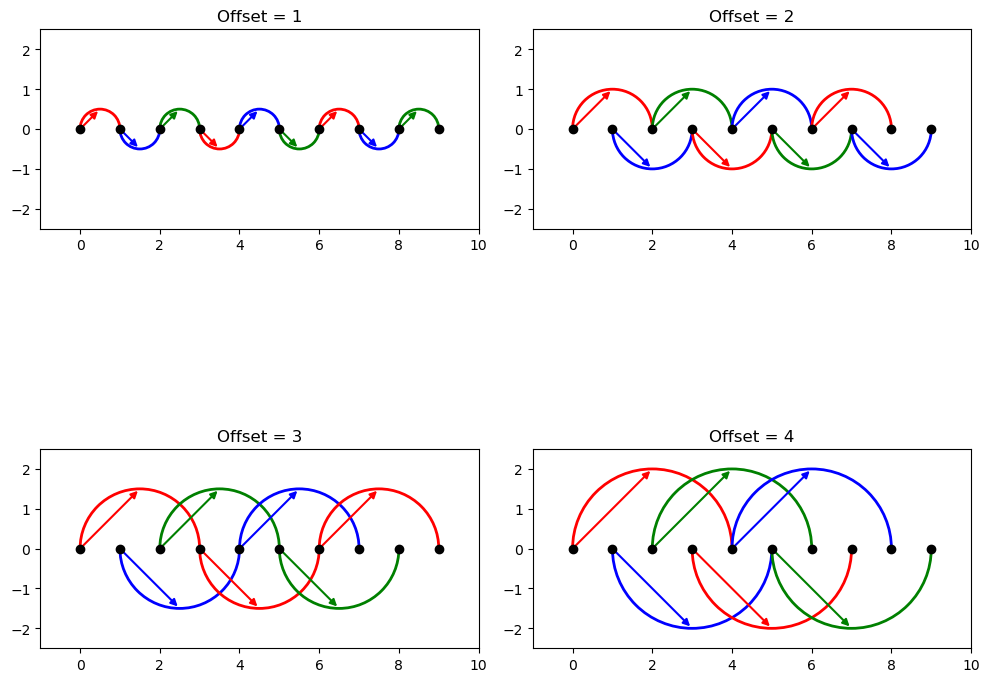

In [111]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Arc

def draw_arcs(ax, n, offset):
    xs = list(range(n))
    ys = [0] * n  # line on y = 0

    ax.plot(xs, ys, 'ko')

    colors = ['red', 'blue', 'green']

    for i in range(n):
        j = i + offset
        if j >= n:
            break

        x0 = xs[i]
        x1 = xs[j]

        xm = (x0 + x1) / 2                     # midpoint x
        radius = (x1 - x0) / 2                 # radius of semicircle
        direction = 1 if i % 2 == 0 else -1    # alternate concave/convex

        ym = radius * direction                # midpoint y for arrow tip
        color = colors[i % len(colors)]

        # Semicircle arc
        arc = Arc(
            (xm, 0),
            width=2*radius,
            height=2*radius,
            angle=0,
            theta1=0 if direction > 0 else 180,
            theta2=180 if direction > 0 else 360,
            color=color,
            linewidth=2
        )
        ax.add_patch(arc)

        # Arrow pointing to the middle of the semicircle
        arrow = FancyArrowPatch(
            (x0, 0),
            (xm, ym),
            connectionstyle="arc3,rad=0.0",  # straight line to midpoint
            arrowstyle="-|>",
            mutation_scale=10,
            color=color,
            linewidth=1.5
        )

        ax.add_patch(arrow)

    ax.set_title(f"Offset = {offset}")
    ax.set_xlim(-1, n)
    ax.set_ylim(-n/4, n/4)
    ax.set_aspect("equal")


def plot_all(n=10):
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))
    offsets = [1, 2, 3, 4]

    idx = 0
    for r in range(2):
        for c in range(2):
            draw_arcs(axs[r][c], n, offsets[idx])
            idx += 1

    plt.tight_layout()
    plt.show()


plot_all(10)


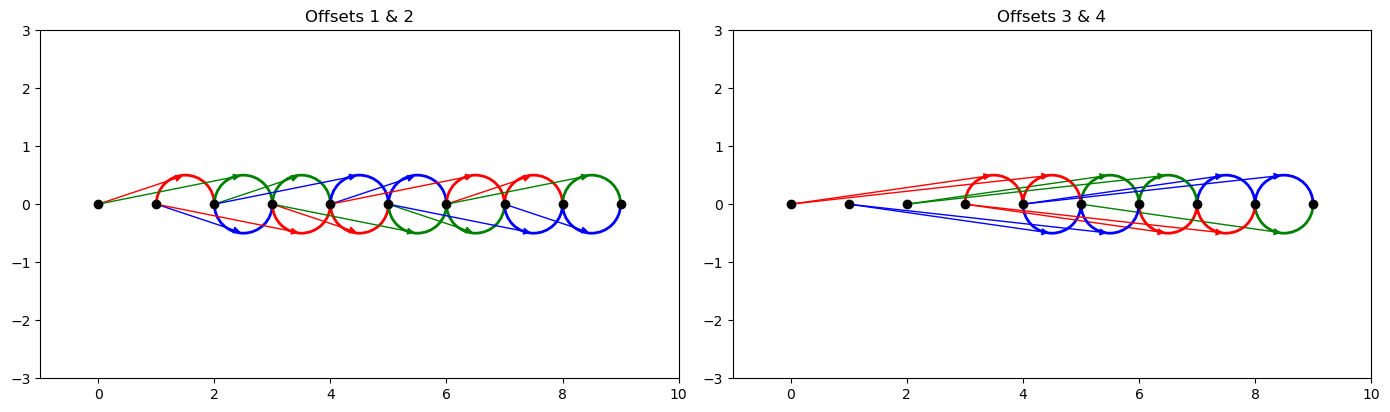

In [112]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Arc

def draw_pairs(ax, n, offsets, title):
    xs = list(range(n))
    ys = [0] * n

    ax.plot(xs, ys, 'ko')

    colors = ["red", "blue", "green"]

    idx = 0

    for offset in offsets:
        for i in range(n):
            j = i + offset
            k = j + 1  # semicircle spans j → j+1

            if k >= n:
                break

            x0 = i
            x1 = j
            x2 = k

            # semicircle from point j to point k
            xm = (x1 + x2) / 2
            radius = (x2 - x1) / 2

            direction = 1 if idx % 2 == 0 else -1  # alternate concave/convex
            ym = radius * direction

            color = colors[idx % len(colors)]

            # Draw semicircle
            arc = Arc(
                (xm, 0),
                width=2 * radius,
                height=2 * radius,
                angle=0,
                theta1=0 if direction > 0 else 180,
                theta2=180 if direction > 0 else 360,
                color=color,
                linewidth=2
            )
            ax.add_patch(arc)

            # Draw arrow from i to midpoint of semicircle
            arrow = FancyArrowPatch(
                (x0, 0),
                (xm, ym),
                arrowstyle="-|>",
                connectionstyle="arc3,rad=0.0",
                mutation_scale=10,
                color=color
            )
            ax.add_patch(arrow)

            idx += 1

    ax.set_title(title)
    ax.set_xlim(-1, n)
    ax.set_ylim(-3, 3)
    ax.set_aspect("equal")


def plot_two_subplots(n=10):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    # subplot A: offsets = 1 and 2
    draw_pairs(axs[0], n, offsets=[1, 2], title="Offsets 1 & 2")

    # subplot B: offsets = 3 and 4
    draw_pairs(axs[1], n, offsets=[3, 4], title="Offsets 3 & 4")

    plt.tight_layout()
    plt.show()


plot_two_subplots(10)


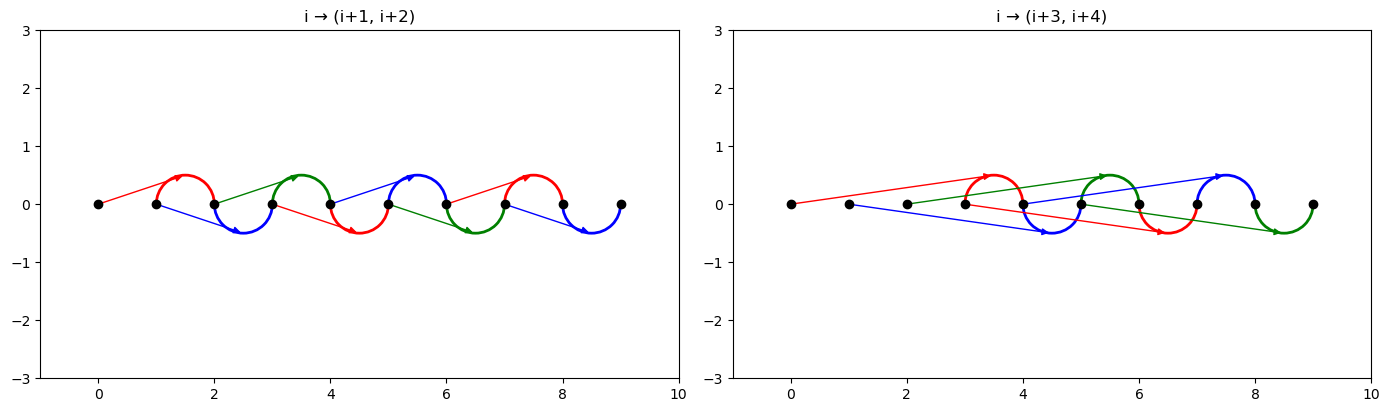

In [113]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Arc

def draw_mapping(ax, n, start_indices, offsets, title):
    xs = list(range(n))
    ys = [0] * n

    ax.plot(xs, ys, 'ko')

    colors = ["red", "blue", "green"]

    for idx, i in enumerate(start_indices):
        a = i + offsets[0]
        b = i + offsets[1]

        if b >= n:
            continue

        # semicircle spans (a, b)
        xm = (a + b) / 2
        radius = (b - a) / 2

        direction = 1 if idx % 2 == 0 else -1
        ym = radius * direction

        color = colors[idx % len(colors)]

        # semicircle
        arc = Arc(
            (xm, 0),
            width=2 * radius,
            height=2 * radius,
            angle=0,
            theta1=0 if direction > 0 else 180,
            theta2=180 if direction > 0 else 360,
            color=color,
            linewidth=2
        )
        ax.add_patch(arc)

        # arrow from i → midpoint of (a,b)
        arrow = FancyArrowPatch(
            (i, 0),
            (xm, ym),
            arrowstyle="-|>",
            connectionstyle="arc3,rad=0",
            mutation_scale=10,
            color=color
        )
        ax.add_patch(arrow)

    ax.set_title(title)
    ax.set_xlim(-1, n)
    ax.set_ylim(-3, 3)
    ax.set_aspect("equal")


def plot_two_subplots(n=10):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    # SUBPLOT 1
    # i = 0..7, pairs are i → (i+1, i+2)
    draw_mapping(
        axs[0],
        n,
        start_indices=range(0, 8),
        offsets=(1, 2),
        title="i → (i+1, i+2)"
    )

    # SUBPLOT 2
    # i = 0..5, pairs are i → (i+3, i+4)
    draw_mapping(
        axs[1],
        n,
        start_indices=range(0, 6),
        offsets=(3, 4),
        title="i → (i+3, i+4)"
    )

    plt.tight_layout()
    plt.show()


plot_two_subplots(10)


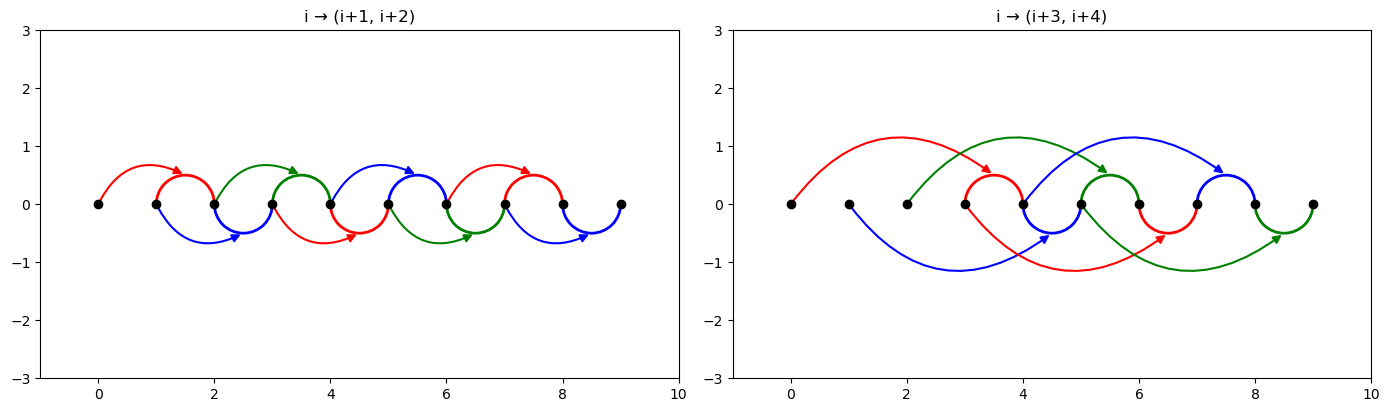

In [114]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Arc

def draw_mapping(ax, n, start_indices, offsets, title):
    xs = list(range(n))
    ys = [0] * n

    ax.plot(xs, ys, 'ko')

    colors = ["red", "blue", "green"]

    for idx, i in enumerate(start_indices):
        a = i + offsets[0]
        b = i + offsets[1]

        if b >= n:
            continue

        # semicircle from a to b
        xm = (a + b) / 2
        radius = (b - a) / 2

        direction = 1 if idx % 2 == 0 else -1
        ym = radius * direction

        color = colors[idx % len(colors)]

        # SEMICIRCLE -------------------------------------------------
        arc = Arc(
            (xm, 0),
            width=2 * radius,
            height=2 * radius,
            angle=0,
            theta1=0 if direction > 0 else 180,
            theta2=180 if direction > 0 else 360,
            color=color,
            linewidth=2
        )
        ax.add_patch(arc)

        # CURVED ARROW (arc3) ----------------------------------------
        # curvature sign opposite semicircle for visual contrast
        curvature = -0.5 * direction  

        arrow = FancyArrowPatch(
            (i, 0),          # start
            (xm, ym),        # end at top/bottom of semicircle
            arrowstyle="-|>",
            mutation_scale=12,
            color=color,
            connectionstyle=f"arc3,rad={curvature}",
            linewidth=1.5
        )

        ax.add_patch(arrow)

    ax.set_title(title)
    ax.set_xlim(-1, n)
    ax.set_ylim(-3, 3)
    ax.set_aspect("equal")


def plot_two_subplots(n=10):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    # First subplot: i → (i+1, i+2)
    draw_mapping(
        axs[0],
        n,
        start_indices=range(0, 8),
        offsets=(1, 2),
        title="i → (i+1, i+2)"
    )

    # Second subplot: i → (i+3, i+4)
    draw_mapping(
        axs[1],
        n,
        start_indices=range(0, 6),
        offsets=(3, 4),
        title="i → (i+3, i+4)"
    )

    plt.tight_layout()
    plt.show()


plot_two_subplots(10)
